In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.catalog.accumulate import *
from compact.catalog.bin import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import os
import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

from pairhist import *

from scipy.optimize import curve_fit

In [2]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 
x2 = r - r_p

In [3]:
SIMS = [i for i in range(130, 180)] # can include last few once they finish


In [4]:
# AS sims run from 130-181
SIMS = [i for i in range(130, 181)]

sim = SIMS[0] #check


OUT_DIR = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
           'cosmo_grid/{sim}/{zdir}/data/')
SB_TMPL = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
           'cosmo_grid/{sim}/{zdir}/SBp/')
LOG_TMPL = ('/spiffball/cosweeney/simulations/AbacusSummit_base/logs/'
            'cosmo_grid/pairhist_{sim}_{zdir}.log')
OUT_NAME = 'pairhist_2bins.h5'


COSMO_COLS = ['omega_b', 'omega_cdm', 'h', 'A_s', 'n_s', 'alpha_s', 'w0_fld', 'wa_fld']

from abacus_cosmo_core import *

box_length = 2000 #Mpc/h, AbacusSummit box side length

test_sim = read_params(141, 0.5)

In [5]:
sim_pars = [read_params(sim, 0.5) for sim in SIMS]

In [6]:
massbins = 10**np.array([[12.5, 12.6], [13.5, 13.6]])
M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

In [65]:
# parallel
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm import tqdm

nus   = 6
REBIN = 5        # 20 km/s fine bins -> 100 km/s
N_MIN = 500

ST_pars = np.full((len(SIMS), len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)
meas_sigv = np.full((len(SIMS), len(M_cens), len(r_p), len(r_l)), np.nan)


def fit_sim_k(si, k, n_k, sum_v_k, sum_v2_k, counts_k, cent, dv):
    out = {}
    for j in range(len(r_p)):
        for i in range(len(r_l)):
            n = n_k[j, i]
            if n < N_MIN:
                continue

            mu    = sum_v_k[j, i] / n
            width = np.sqrt(max(sum_v2_k[j, i] / n - mu**2, 0.0))

            counts   = counts_k[j, i].reshape(-1, REBIN).sum(axis=1)
            sel      = np.abs(cent - mu) <= 2500
            c_w, x_w = counts[sel], cent[sel]
            if c_w.sum() == 0:
                continue

            hist = c_w / (c_w.sum() * dv)

            try:
                p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                 x_w, hist, p0=[mu, width, -0.1], method='lm', maxfev=5_000)
            except RuntimeError:
                continue
            out[(j, i)] = (p, np.sqrt(np.diag(c)), width)
    return si, k, out

sim_data = []
for si, sim in enumerate(SIMS):
    OUT_DIR = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
               f'cosmo_grid/c{sim}_ph000/z0p500/data/') + OUT_NAME

    h = PairHist.load(OUT_DIR)
    assert len(r_p) == h.n_R and len(r_l) == h.n_l

    cent_fine = h.v_centers
    dv        = (cent_fine[1] - cent_fine[0]) * REBIN
    cent      = cent_fine.reshape(-1, REBIN).mean(axis=1)

    sim_data.append((si, h.n, h.sum_v, h.sum_v2, h.counts, cent, dv))
    del h

tasks = [
    (si, k, n[k], sum_v[k], sum_v2[k], counts[k], cent, dv)
    for si, n, sum_v, sum_v2, counts, cent, dv in sim_data
    for k in range(len(M_cens))
]

with tqdm_joblib(tqdm(total=len(tasks), desc="Fitting skew-T (all sims/mass bins)")):
    results = Parallel(n_jobs=84)(
        delayed(fit_sim_k)(*t) for t in tasks
    )

for si_, k, out in results:
    for (j, i), (p, err, width) in out.items():
        ST_pars[si_, k, j, i] = p
        ST_errs[si_, k, j, i] = err
        meas_sigv[si_, k, j, i]     = width

Fitting skew-T (all sims/mass bins):   0%|          | 0/102 [00:00<?, ?it/s]

  0%|          | 0/102 [00:00<?, ?it/s]

In [67]:
# save pars

save_path = '/spiffball/cosweeney/simulations/AbacusSummit_base/halos/cosmo_grid/data/ST_pars_cosmo.h5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('ST_pars', data=ST_pars)
    hdf.create_dataset('ST_errs', data=ST_errs)
    hdf.create_dataset('meas_sigv', data=meas_sigv)

    hdf.attrs['sims'] = SIMS

In [7]:
# load pars 

save_path = '/spiffball/cosweeney/simulations/AbacusSummit_base/halos/cosmo_grid/data/ST_pars_cosmo.h5'

with h5.File(save_path, 'r') as hdf:
    ST_pars = hdf['ST_pars'][()]
    ST_errs = hdf['ST_errs'][()]
    meas_sigv = hdf['meas_sigv'][()]

    SIMS = hdf.attrs['sims']

In [7]:
# measure radial velocity profiles 

from scipy.interpolate import InterpolatedUnivariateSpline

def vr_profile(h, k, r_edges=None, r_max_trust=None):
    """Pair-weighted <v_r>(r) and sigma_vr(r) for mass bin k.

    Returns (r_eff, mean_vr, sigma_vr, n_pairs), all length len(r_edges)-1.
    r_eff is the pair-weighted mean radius in each bin, not the bin centre.
    Units follow the accumulator -- km/s if conv was applied at accumulation.
    """
    Rc = 0.5 * (h.R_edges[1:] + h.R_edges[:-1])
    lc = 0.5 * (h.rlos_edges[1:] + h.rlos_edges[:-1])
    r3 = np.sqrt(Rc[:, None]**2 + lc[None, :]**2).ravel()

    n = h.n[k].ravel().astype(float)
    s1 = h.sum_vr[k].ravel()
    s2 = h.sum_vr2[k].ravel()

    if r_edges is None:
        # default: 2 Mpc/h bins out to the largest radius with full angular
        # coverage (beyond R_edges[-1] only the cylinder corners contribute)
        top = r_max_trust if r_max_trust is not None else h.R_edges[-1]
        r_edges = np.arange(0.0, top + 2.0, 2.0)

    nb_bins = len(r_edges) - 1
    idx = np.searchsorted(r_edges, r3, side='right') - 1
    ok = (idx >= 0) & (idx < nb_bins) & (n > 0)

    def acc(w):
        return np.bincount(idx[ok], weights=w[ok], minlength=nb_bins)

    N = acc(n)
    r_eff = np.where(N > 0, acc(n * r3) / np.where(N > 0, N, 1), np.nan)
    mu = np.where(N > 0, acc(s1) / np.where(N > 0, N, 1), np.nan)
    m2 = np.where(N > 0, acc(s2) / np.where(N > 0, N, 1), np.nan)
    sd = np.sqrt(np.maximum(m2 - mu**2, 0.0))
    return r_eff, mu, sd, N.astype(np.int64)


def make_vr_interp(h, k, r_edges=None, r_max_trust=None, n_min=1000, ext=3):
    """Spline interpolator for <v_r>(r), analogous to mean_vr_r_interp.

    ext=3 clamps to the end values outside the fitted range rather than
    extrapolating or returning NaN -- your r_3d reaches ~198 Mpc/h at the grid
    corners, and a spline let loose out there will do something wild.
    """
    r, mu, _, N = vr_profile(h, k, r_edges, r_max_trust)
    good = np.isfinite(mu) & (N >= n_min)
    if good.sum() < 4:
        raise ValueError(f'mass bin {k}: only {good.sum()} usable radial bins')
    return InterpolatedUnivariateSpline(r[good], mu[good], k=3, ext=ext)

In [8]:
sim_interps = []
for sim in SIMS:
    OUT_DIR = ('/spiffball/cosweeney/simulations/AbacusSummit_base/halos/'
               f'cosmo_grid/c{sim}_ph000/z0p500/data/') + OUT_NAME
    
    h = PairHist.load(OUT_DIR)
    for k in range(len(M_cens)):
        interp = make_vr_interp(h, k) 

        sim_interps.append(interp)


In [10]:
import camb
from camb import model

sigmas = np.zeros(len(SIMS))

def get_sigma0_nl(params, redshift, kmax=10.0, npoints=500):
    H0 = params['h'] * 100.0
    mnu = params['omega_ncdm'] * 93.14

    pars = camb.set_params(
        H0=H0,
        ombh2=params['omega_b'],
        omch2=params['omega_cdm'],
        ns=params['n_s'],
        As=params['A_s'],
        nrun=params['alpha_s'],
        mnu=mnu,
        num_massive_neutrinos=int(round(params['N_ncdm'])),
        nnu=params['N_ur'] + params['N_ncdm'],
        w=params['w0_fld'],
        wa=params['wa_fld'],
        dark_energy_model='ppf',
    )
    pars.set_matter_power(redshifts=[redshift], kmax=kmax)
    pars.NonLinear = model.NonLinear_both

    results = camb.get_results(pars)
    kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
        minkh=1e-4, maxkh=5.0, npoints=npoints
    )
    pk_nl = pk_nl[0]

    h = params['h']
    Om0 = params['Omega_M']
    Omz = Om0 * (1.0 + redshift)**3 / (H0 / (100.0 * h))**2
    f = Omz**0.55

    a = 1 / (1 + redshift)
    conv = a * H0 / h

    sigma0_nl_sq = (f * conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
    return np.sqrt(sigma0_nl_sq)

for si, sim in enumerate(SIMS):
    sigmas[si] = get_sigma0_nl(sim_pars[si], 0.0)

In [ ]:

from scipy.optimize import curve_fit
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens,
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]
names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

PLOT_DIR = 'diagnostic_plots/abacus/'
os.makedirs(PLOT_DIR, exist_ok=True)

SIG_FLOOR = 0.1      # km/s, drop unfit/empty cells
DEL_FLOOR = -1000.0  # km/s

n_sim, n_R = len(SIMS), len(r_p)
n_M = meas_sigv.shape[1]

sig_opts = np.full((n_sim, n_M, 4), np.nan)   # sigma0, A_piv, b, sigma_rho
sig_errs = np.full_like(sig_opts, np.nan)
sig_corr = np.full((n_sim, n_M, 4, 4), np.nan)
R_pivs   = np.full((n_sim, n_M), np.nan)
del_opts = np.full((n_sim, n_M, 2), np.nan)
del_errs = np.full_like(del_opts, np.nan)
A_rho_R     = np.full((n_sim, n_M, n_R), np.nan)
A_rho_R_err = np.full_like(A_rho_R, np.nan)

skip = 5   # plotting stride only; the fits use every R bin
xs = np.linspace(x.min() * 0.8, x.max() * 1.2, 1000)

# ---------------------------------------------------------------- models
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    arg = 2.0 * sigma0**2 * (1.0 - A_rho * np.exp(-x / sigma_rho))
    return np.sqrt(np.clip(arg, 1e-8, None))


def A_rho_mod(R, A_piv, b, R_piv):
    return A_piv * np.exp(-(R - R_piv) / b)


def sigma_mod_2d(coords, sigma0, A_piv, b, sigma_rho, R_piv):
    x, R = coords
    return sigma_mod(x, sigma0, A_rho_mod(R, A_piv, b, R_piv), sigma_rho)


def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)


# ---------------------------------------------------------------- fitting
def _seed(x, R, sig, R_piv):
    """Linearised seed. With y = 2 sigma0^2 - sigma_v^2,

        log y = log(2 sigma0^2 A_piv) - (R - R_piv)/b - x/sigma_rho

    is linear in (R, x), so an lstsq gives starting values for free."""
    sigma0 = sig.max() / np.sqrt(2.0) * 1.02
    y = 2.0 * sigma0**2 - sig**2
    m = y > 0
    G = np.column_stack([np.ones(m.sum()), -(R[m] - R_piv), -x[m]])
    c = np.linalg.lstsq(G, np.log(y[m]), rcond=None)[0]

    b = 1.0 / c[1] if c[1] > 0 else np.ptp(R) + 1.0
    sigma_rho = 1.0 / c[2] if c[2] > 0 else 10.0
    A_piv = np.clip(np.exp(c[0]) / (2.0 * sigma0**2), 1e-3, 0.99)
    return [sigma0, A_piv, b, sigma_rho]


def fit_sigma_joint(x, r_p, sig, R_piv=None):
    """Single fit for (sigma0, A_piv, b, sigma_rho) using every (R, x) cell."""
    R = np.broadcast_to(r_p[:, None], x.shape)
    m = np.isfinite(x) & np.isfinite(sig) & (sig > SIG_FLOOR)
    X, RR, S = x[m], R[m], sig[m]

    if R_piv is None:
        R_piv = np.median(RR)

    # if np.sum(np.isnan(S)) == len(S.flatten()):
    #     print(sig.min(), m)

    popt, pcov = curve_fit(
        lambda c, s0, Ap, b, sr: sigma_mod_2d(c, s0, Ap, b, sr, R_piv),
        (X, RR), S, p0=_seed(X, RR, S, R_piv),
        bounds=([0.0, 1e-4, 1e-3, 1e-3], [np.inf, 1.0, np.inf, np.inf]),
        maxfev=20_000,
    )
    perr = np.sqrt(np.diag(pcov))
    corr = pcov / np.outer(perr, perr)
    return popt, perr, corr, R_piv


def fit_A_per_R(x, sig, sigma0, sigma_rho):
    """Old per-R_perp fit, kept as a diagnostic: is A_rho(R) really exponential?"""
    A = np.full(x.shape[0], np.nan)
    Aerr = np.full(x.shape[0], np.nan)
    for j in range(x.shape[0]):
        m = np.isfinite(x[j]) & np.isfinite(sig[j]) & (sig[j] > SIG_FLOOR)
        if m.sum() < 3:
            continue
        p, c = curve_fit(lambda xx, a: sigma_mod(xx, sigma0, a, sigma_rho),
                         x[j][m], sig[j][m], p0=[0.3],
                         bounds=(1e-4, 1.0), maxfev=10_000)
        A[j], Aerr[j] = p[0], np.sqrt(c[0, 0])
    return A, Aerr


def fit_delta(x, D):
    m = np.isfinite(x) & np.isfinite(D) & (D > DEL_FLOOR)
    popt, pcov = curve_fit(delta_mod, x[m], D[m], p0=[100.0, 1.0], maxfev=10_000)
    return popt, np.sqrt(np.diag(pcov))


for si, sim in tqdm(enumerate(SIMS)):
    cmap_k = colormap_list[si % len(colormap_list)]

    fig, ax = plt.subplots(n_M, 3, figsize=(15, 5 * n_M),
                           layout='constrained', sharex='col', squeeze=False)
    fig.suptitle(rf"{sim}", fontsize=20)

    drew = False

    for k in range(n_M):
        sig = meas_sigv[si, k]
        Delta = ST_pars[si, k, :, :, 0] - sim_interps[si](r) * r_l / r

        if np.isnan(sig).all() or np.isnan(Delta).all():
            continue

        # --- fits -------------------------------------------------------
        popt, perr, corr, R_piv = fit_sigma_joint(x, r_p, sig)
        sig_opts[si, k], sig_errs[si, k], sig_corr[si, k] = popt, perr, corr
        R_pivs[si, k] = R_piv
        del_opts[si, k], del_errs[si, k] = fit_delta(x, Delta)

        A_rho_R[si, k], A_rho_R_err[si, k] = fit_A_per_R(x, sig, popt[0], popt[3])
        drew = True

        # --- panel 0: sigma_v^2 vs x, one curve per R -------------------
        colors = cmap_k(np.linspace(0.3, 1, n_R))
        for j in range(0, n_R, skip):
            m = sig[j] > SIG_FLOOR
            ax[k, 0].plot(x[j][m], sig[j][m]**2, 'o', c=colors[j])
            ax[k, 0].plot(xs, sigma_mod(xs, popt[0],
                                        A_rho_mod(r_p[j], popt[1], popt[2], R_piv),
                                        popt[3])**2, c=colors[j], ls='--')
        ax[k, 0].axhline(2 * popt[0]**2, c='purple', ls='--')
        ax[k, 0].axhline(2 * 355.0**2, c='k', ls=':', alpha=0.5)
        ax[k, 0].set(xscale='log', yscale='log',
                     ylabel=names[0], title=f'mass bin {k}')

        # --- panel 1: Delta --------------------------------------------
        for j in range(0, n_R, skip):
            m = Delta[j] > DEL_FLOOR
            ax[k, 1].plot(x[j][m], Delta[j][m], 'o', c=colors[j])
        ax[k, 1].plot(xs, delta_mod(xs, *del_opts[si, k]), c='purple')
        ax[k, 1].set(xscale='log', ylabel=names[1])

        # --- panel 2: A_rho(R), joint fit vs per-bin --------------------
        ax[k, 2].errorbar(r_p, A_rho_R[si, k], A_rho_R_err[si, k],
                          fmt='o', c='k', ms=3, label='per-$R$ fit')
        ax[k, 2].plot(r_p, A_rho_mod(r_p, popt[1], popt[2], R_piv),
                      c='purple', label='joint exp. fit')
        ax[k, 2].set(xlabel=r'$R\ [h^{-1}$ Mpc]', ylabel=r'$A_\rho$')
        ax[k, 2].legend(fontsize=8)

        sm = ScalarMappable(norm=Normalize(vmin=r_p.min(), vmax=r_p.max()), cmap=cmap_k)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax[k, 1])
        cbar.set_label(rf"$R\ [h^{{-1}}$ Mpc]", fontsize=10)

    if drew:
        for i in range(2):
            ax[-1, i].set_xlabel(r'$r-R$', fontsize=20)
        fig.savefig(os.path.join(PLOT_DIR, f'compact_fit_{sim}.png'), dpi=120)

    plt.close(fig)

0it [00:00, ?it/s]

51it [03:05,  3.64s/it]


In [12]:
# save compact pars 
save_path = '/spiffball/cosweeney/simulations/AbacusSummit_base/halos/cosmo_grid/data/compact_pars_cosmo_z0p500.h5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset(name='sig_opts', data=sig_opts)
    hdf.create_dataset(name='sig_errs', data=sig_errs) 
    hdf.create_dataset(name='sig_corr', data=sig_corr) 
    hdf.create_dataset(name='R_pivs', data=R_pivs)   
    hdf.create_dataset(name='del_opts', data=del_opts) 
    hdf.create_dataset(name='del_errs', data=del_errs) 
    hdf.create_dataset(name='A_rho_R', data=A_rho_R)  
    hdf.create_dataset(name='A_rho_R_err', data=A_rho_R_err) 

    hdf.attrs['n_sim'] = n_sim
    hdf.attrs['n_R'] = n_R
    hdf.attrs['n_M'] = n_M 

In [13]:
# load compact pars 
save_path = '/spiffball/cosweeney/simulations/AbacusSummit_base/halos/cosmo_grid/data/compact_pars_cosmo_z0p500.h5'

with h5.File(save_path, 'r') as hdf:
    sig_opts=hdf['sig_opts'][()]
    sig_errs=hdf['sig_errs'][()]  
    sig_corr=hdf['sig_corr'][()] 
    R_pivs=hdf['R_pivs'][()]    
    del_opts=hdf['del_opts'][()] 
    del_errs=hdf['del_errs'][()]  
    A_rho_R=hdf['A_rho_R'][()]   
    A_rho_R_err=hdf['A_rho_R_err'][()] 

    n_sim = hdf.attrs['n_sim']
    n_R = hdf.attrs['n_R']
    n_M = hdf.attrs['n_M'] 

In [11]:
cosmo_arr = np.array([[sim_pars[i]['omega_b'], 
                       sim_pars[i]['omega_cdm'], 
                       sim_pars[i]['sigma8_m'], 
                       sim_pars[i]['n_s'], 
                       sim_pars[i]['alpha_s'], 
                       sim_pars[i]['N_ur'],
                       sim_pars[i]['w0_fld'],
                       sim_pars[i]['wa_fld']]    for i in range(len(SIMS))])

lcdm_arr = np.array([[sim_pars[i]['omega_b'], 
                       sim_pars[i]['omega_cdm'], 
                       np.log(10**10*sim_pars[i]['A_s']), 
                       sim_pars[i]['n_s'], 
                       ]    for i in range(len(SIMS))])

lcdm_arr.shape

(51, 4)

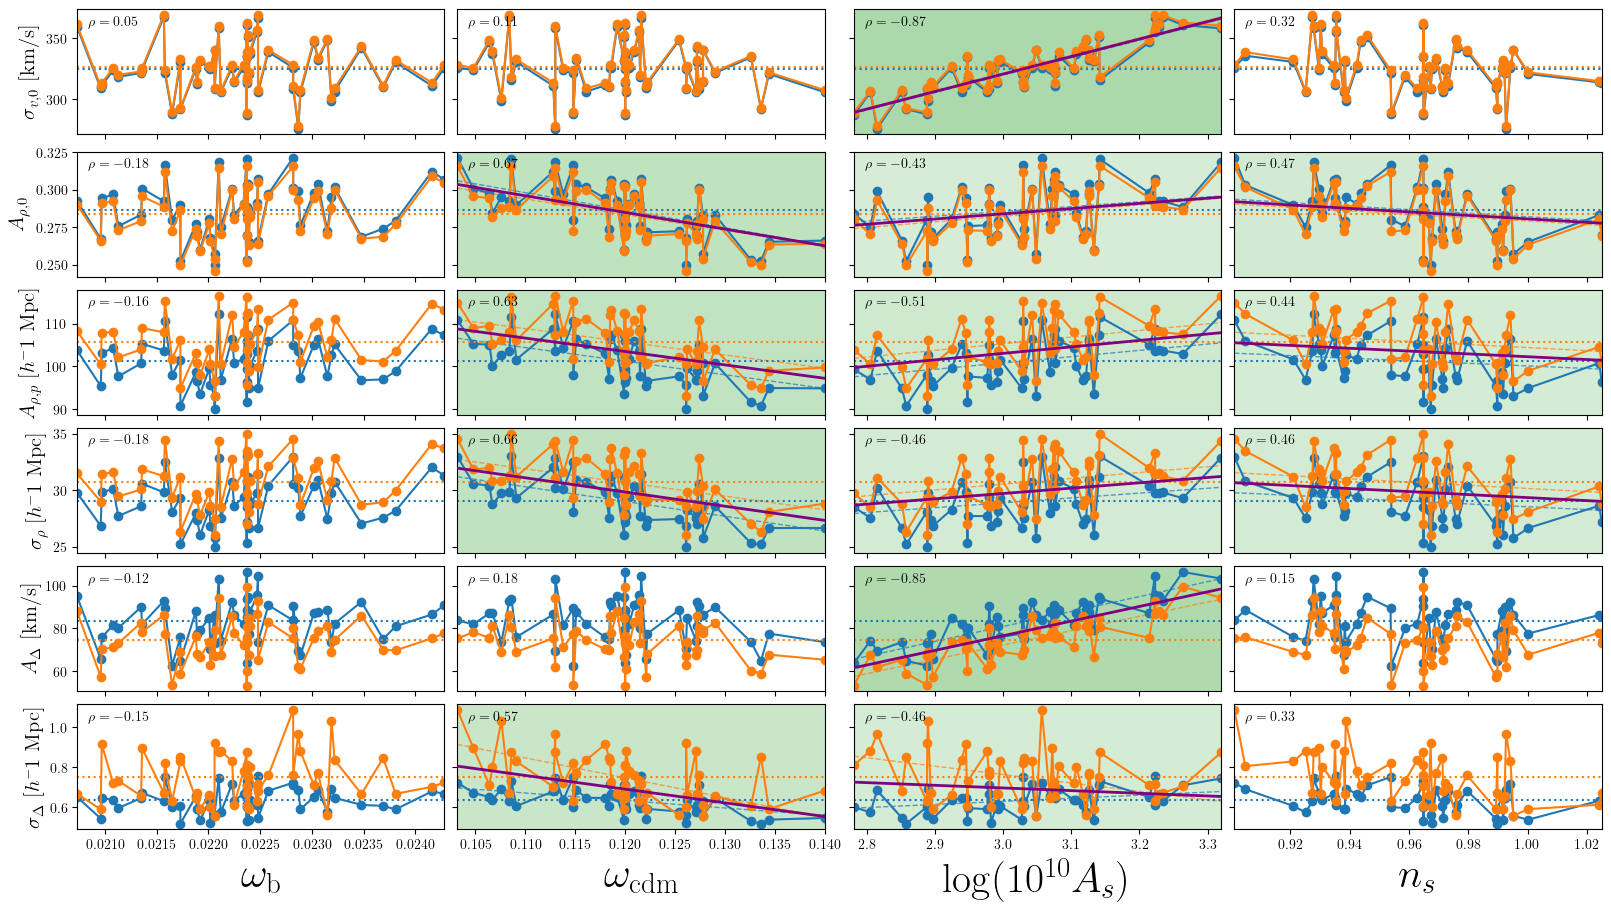

In [17]:
from scipy.stats import spearmanr, pearsonr
from matplotlib.colors import to_rgba

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$A_{\rho, p}$ [$h^-1$ Mpc]",
          r"$\sigma_\rho$ [$h^-1$ Mpc]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [$h^-1$ Mpc]"]
c_labels = [r"$\omega_{\rm b}$", r"$\omega_{\rm cdm}$", r"$\log(10^{10}A_s)$", r"$n_s$"]

n_M      = parameters.shape[1]
n_labels = len(labels)
n_cpars  = len(c_labels)

# AbacusSummit c000 (Planck2018) fiducial cosmology, same column order as c_labels
FIDUCIAL_COSMO = np.array([0.02237, 0.1200, np.log(1e10 * 2.0830e-9), 0.9649])
delta_arr = FIDUCIAL_COSMO[None, :] - lcdm_arr    # Delta_theta = theta_fid - theta

fig, ax = plt.subplots(n_labels, n_cpars, figsize=(16, 9), sharex='col', sharey='row', layout='constrained')

RHO_MIN  = 0.3
P_MAX    = 0.05 / (n_labels * n_cpars)
ALPHA_MAX = 0.45

cos_em_pars       = []   # simultaneous fit: [intercept, beta_j1, ...] per fitted row
cos_em_cov        = []
cos_em_pars_indiv = []   # per-mass fits: (n_M, n_dependent+1) array per fitted row, diagnostic only
em_inds           = []   # (row index i, [dependent column indices])

for i in range(n_labels):
    rhos, dependent_cols = {}, []
    for j in range(n_cpars):
        x_plot = delta_arr[:, j]
        good = np.isfinite(parameters[:, 0, i])
        rho, p = pearsonr(x_plot[good], parameters[good, 0, i])
        rhos[j] = rho
        if (abs(rho) >= RHO_MIN) and (p < P_MAX):
            dependent_cols.append(j)

    beta = other_means = beta_indiv = None
    if dependent_cols:
        X = np.column_stack([np.ones(delta_arr.shape[0])] +
                             [delta_arr[:, j] for j in dependent_cols])

        # -- simultaneous fit across mass bins --
        X_rep = np.repeat(X, n_M, axis=0)
        y = parameters[:, :, i].flatten()
        good = np.isfinite(y)

        beta, *_ = np.linalg.lstsq(X_rep[good], y[good], rcond=None)
        resid = y[good] - X_rep[good] @ beta
        dof = good.sum() - X_rep.shape[1]
        cov = (np.sum(resid**2) / dof) * np.linalg.inv(X_rep[good].T @ X_rep[good])

        cos_em_pars.append(beta)
        cos_em_cov.append(cov)
        em_inds.append((i, dependent_cols))

        # -- individual per-mass-bin fits (diagnostic) --
        beta_indiv = np.full((n_M, X.shape[1]), np.nan)
        for k in range(n_M):
            good_k = np.isfinite(parameters[:, k, i])
            beta_indiv[k], *_ = np.linalg.lstsq(X[good_k], parameters[good_k, k, i], rcond=None)
        cos_em_pars_indiv.append(beta_indiv)

        # raw-theta means, used to hold non-x-axis predictors fixed when plotting partial dependence
        other_means = {jj: FIDUCIAL_COSMO[jj] - np.nanmean(delta_arr[:, jj]) for jj in dependent_cols}

    for j in range(n_cpars):
        x_plot = lcdm_arr[:, j]     # panels stay in raw-theta space for readability
        order = np.argsort(x_plot)
        dependent = j in dependent_cols

        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red',
                                        ALPHA_MAX * min(abs(rhos[j]), 1.0) if dependent else 0.0))
        ax[i, j].text(0.03, 0.95, rf'$\rho={rhos[j]:.2f}$', transform=ax[i, j].transAxes,
                      va='top', fontsize=10)

        if dependent:
            x_smooth = np.linspace(x_plot.min(), x_plot.max(), 50)
            d_smooth = FIDUCIAL_COSMO[j] - x_smooth   # convert x-axis (raw theta) to Delta_theta

            def eval_fit(coef, xj):
                return coef[0] + sum(
                    coef[1 + idx2] * (xj if jj == j else FIDUCIAL_COSMO[jj] - other_means[jj])
                    for idx2, jj in enumerate(dependent_cols)
                )

            ax[i, j].plot(x_smooth, eval_fit(beta, d_smooth), c='purple', ls='-', lw=2, zorder=5)
            for k in range(n_M):
                ax[i, j].plot(x_smooth, eval_fit(beta_indiv[k], d_smooth), c=f'C{k}', ls='--', lw=1, alpha=0.7)

        for k in range(n_M):
            ax[i, j].plot(x_plot[order], parameters[order, k, i], marker='o', c=f'C{k}')
            ax[i, j].axhline(np.nanmean(parameters[order, k, i]), c=f'C{k}', ls=':')

        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
        ax[i, j].margins(x=0)

    ax[i, 0].set_ylabel(labels[i], fontsize=15)

Text(0.5, 0.98, 'Spread about best-fit line for cosmo dependence\n AbacusSummit @ $z=0.5$')

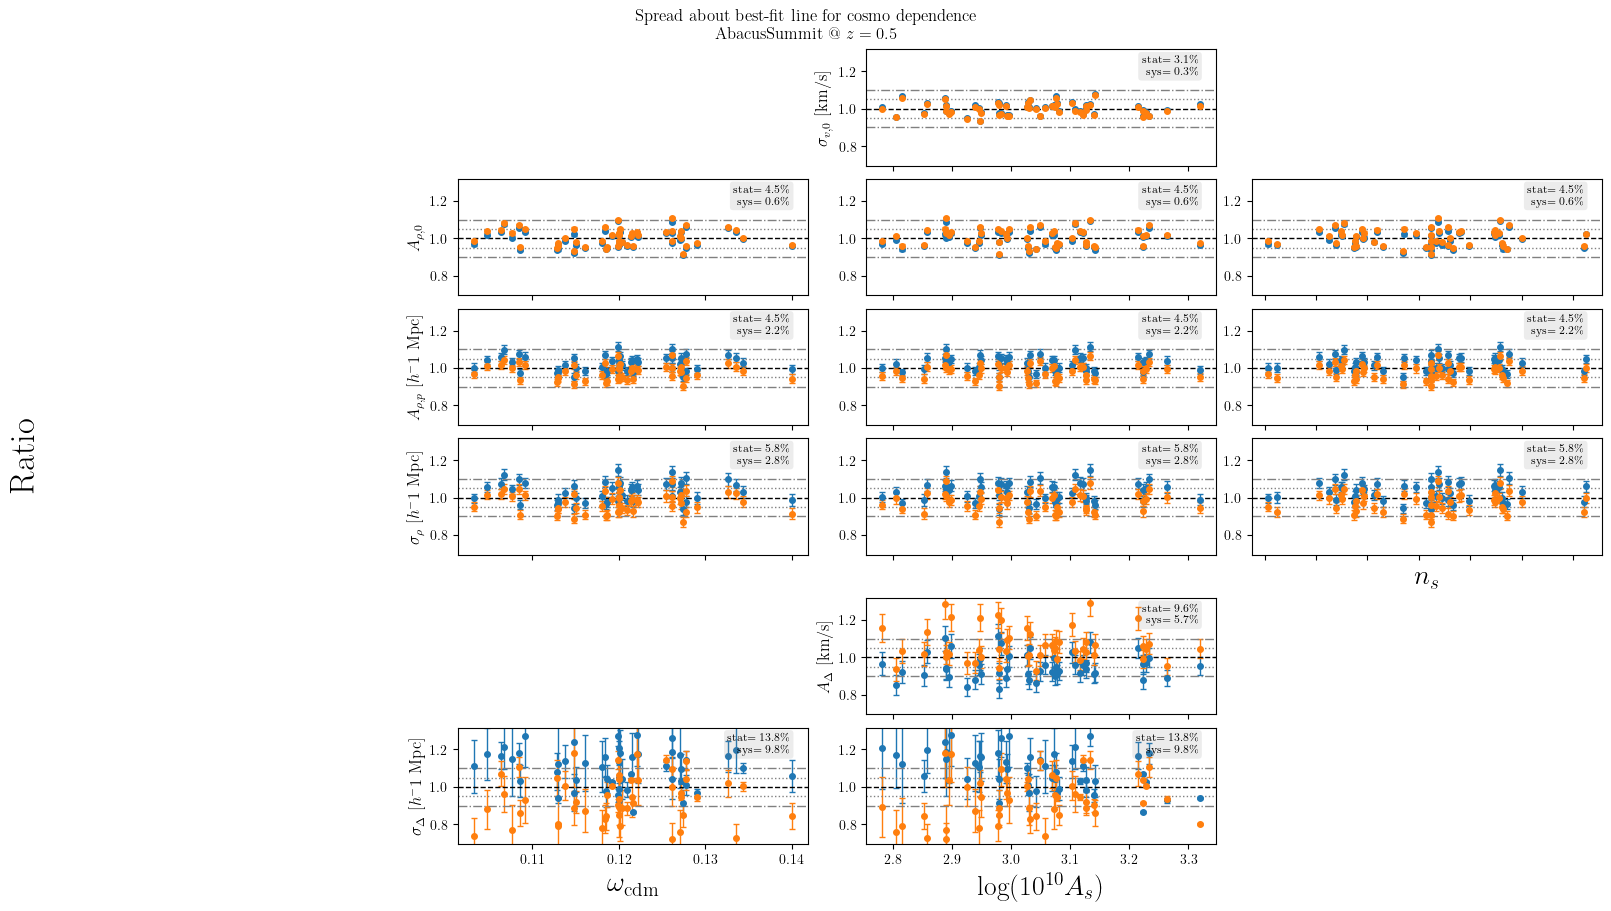

In [15]:
fig2, ax2 = plt.subplots(n_labels, n_cpars, figsize=(16, 9), sharex='col', layout='constrained')
for i in range(n_labels):
    for j in range(n_cpars):
        ax2[i, j].axis('off')

last_visible_row = {}
all_ratios = []

for (i, dependent_cols), beta, beta_indiv in zip(em_inds, cos_em_pars, cos_em_pars_indiv):
    X = np.column_stack([np.ones(delta_arr.shape[0])] +
                         [delta_arr[:, j] for j in dependent_cols])

    pred_simul = X @ beta                                    # (n_sim,)
    ratio = pred_simul[:, None] / parameters[:, :, i]         # (n_sim, n_M)
    stat_rms = np.sqrt(np.nanmean((ratio - 1)**2))
    all_ratios.append(ratio)

    pred_indiv = np.stack([X @ beta_indiv[k] for k in range(n_M)], axis=1)   # (n_sim, n_M)
    sys_frac = (pred_indiv - pred_simul[:, None]) / parameters[:, :, i]      # fractional systematic
    sys_rms = np.sqrt(np.nanmean(sys_frac**2))

    for j in dependent_cols:
        x_plot = lcdm_arr[:, j]
        ax2[i, j].axis('on')
        for k in range(n_M):
            ax2[i, j].errorbar(x_plot, ratio[:, k], yerr=np.abs(sys_frac[:, k]),
                               fmt='o', c=f'C{k}', ms=4, capsize=2, elinewidth=1)
        ax2[i, j].axhline(1, c='k', ls='--', lw=1)
        for band, ls in [(0.05, ':'), (0.10, '-.')]:
            ax2[i, j].axhline(1 + band, c='gray', ls=ls, lw=1)
            ax2[i, j].axhline(1 - band, c='gray', ls=ls, lw=1)
        
        stat_str = rf'stat$={stat_rms:.1%}$'.replace('%', r'\%')
        sys_str  = rf'sys$={sys_rms:.1%}$'.replace('%', r'\%')
        ax2[i, j].text(0.95, 0.95, stat_str + '\n' + sys_str,
                       transform=ax2[i, j].transAxes, va='top', ha='right', fontsize=8,
                       bbox=dict(facecolor='gray', alpha=0.15, edgecolor='none', boxstyle='round,pad=0.3'))

        last_visible_row[j] = max(last_visible_row.get(j, -1), i)

    ax2[i, dependent_cols[0]].set_ylabel(labels[i], fontsize=12)

for j, i in last_visible_row.items():
    ax2[i, j].set_xlabel(c_labels[j], fontsize=20)

all_ratios = np.concatenate([r.flatten() for r in all_ratios])
all_ratios = all_ratios[np.isfinite(all_ratios)]
ymin = min(all_ratios.min(), 0.90)
ymax = max(all_ratios.max(), 1.10)
pad = 0.05 * (ymax - ymin)
for i in range(n_labels):
    for j in range(n_cpars):
        if ax2[i, j].axison:
            ax2[i, j].set_ylim(ymin - pad, ymax + pad)

fig2.supylabel('Ratio', fontsize=25)

fig2.suptitle('Spread about best-fit line for cosmo dependence\n AbacusSummit @ $z=0.5$')

In [82]:
# The AbacusSummit emulator grids represent sampled sub-spaces; not a latin-hypercube type sample.
# I'm defining the cases here with masks
mask_typ = (np.array(SIMS) >= 130) & (np.array(SIMS) <= 146) # 17 sims, vary omb, omcdm, s8, and ns only 
mask_w0wa = (np.array(SIMS) >= 147) & (np.array(SIMS) <= 160) # 14 sims, vary only w0 and wa
mask_spec = (np.array(SIMS) >= 161) & (np.array(SIMS) <= 174) # 14 sims, only alpha_s and N_ur vary
mask_free = (np.array(SIMS) >= 175) & (np.array(SIMS) <= 181) # 7 sims, all parameters varied. 

masks = [mask_typ, mask_w0wa, mask_spec, mask_free]


In [84]:
for mask in masks:
    print(mask.sum())

17
14
14
6


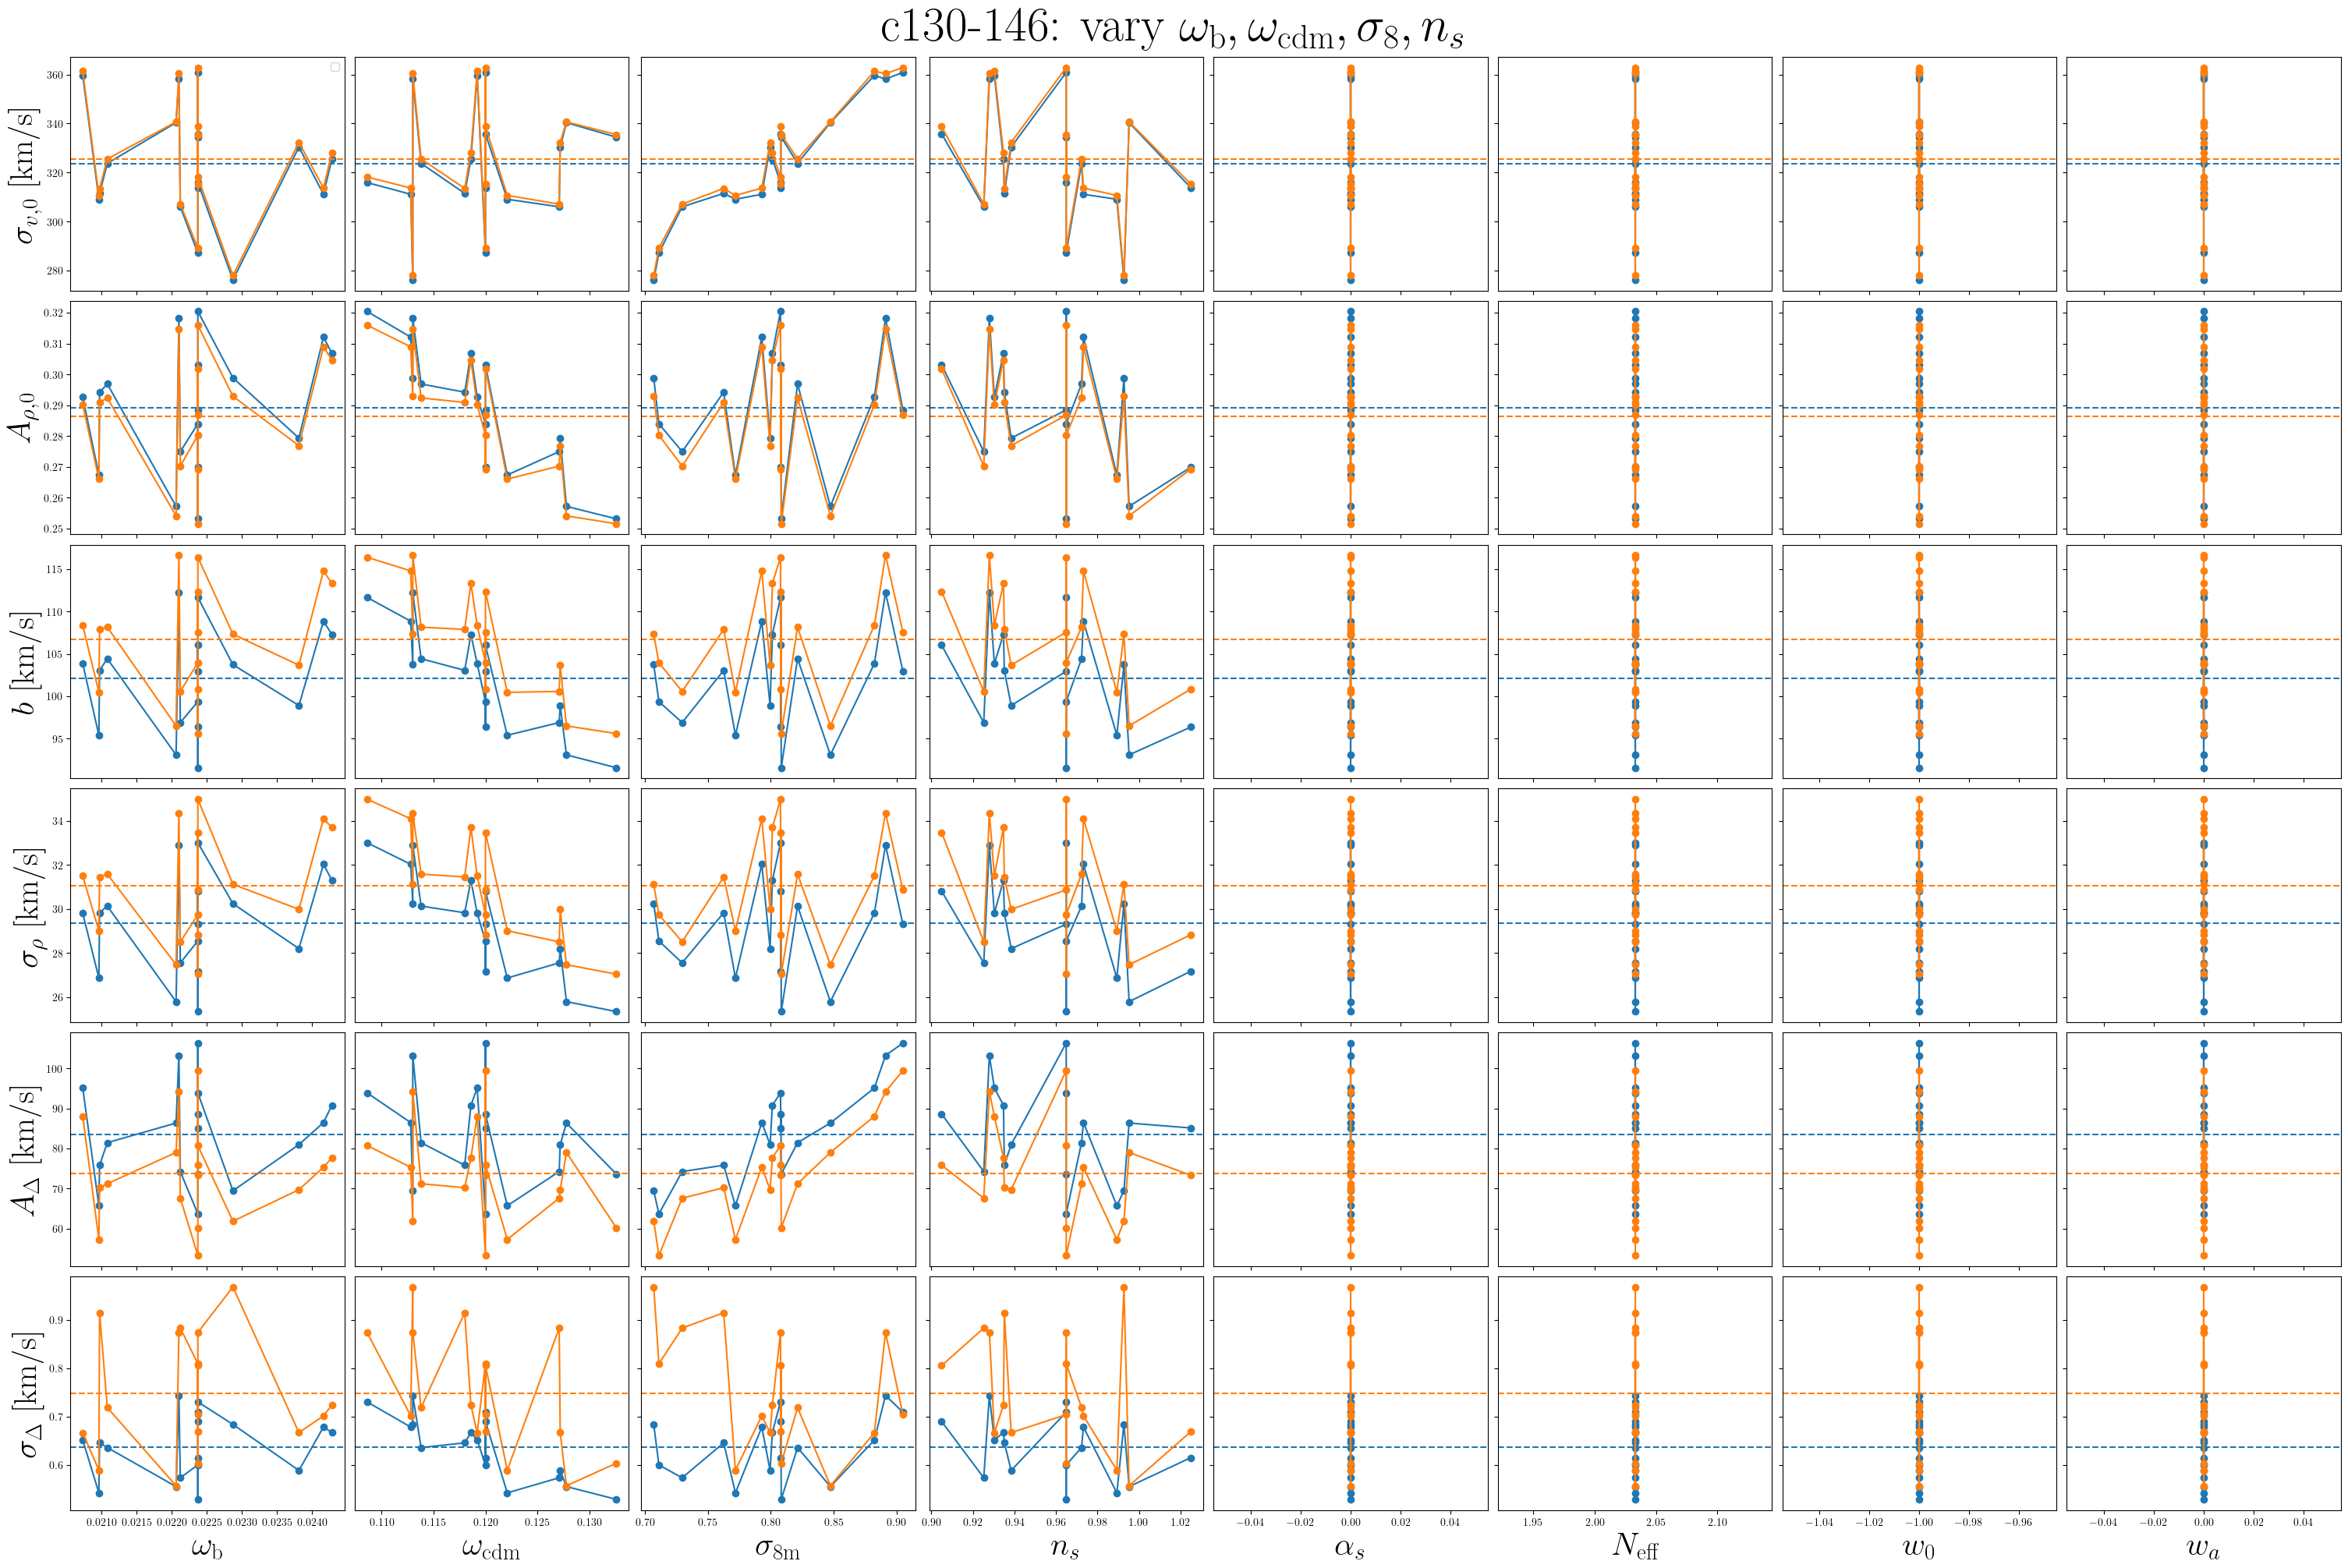

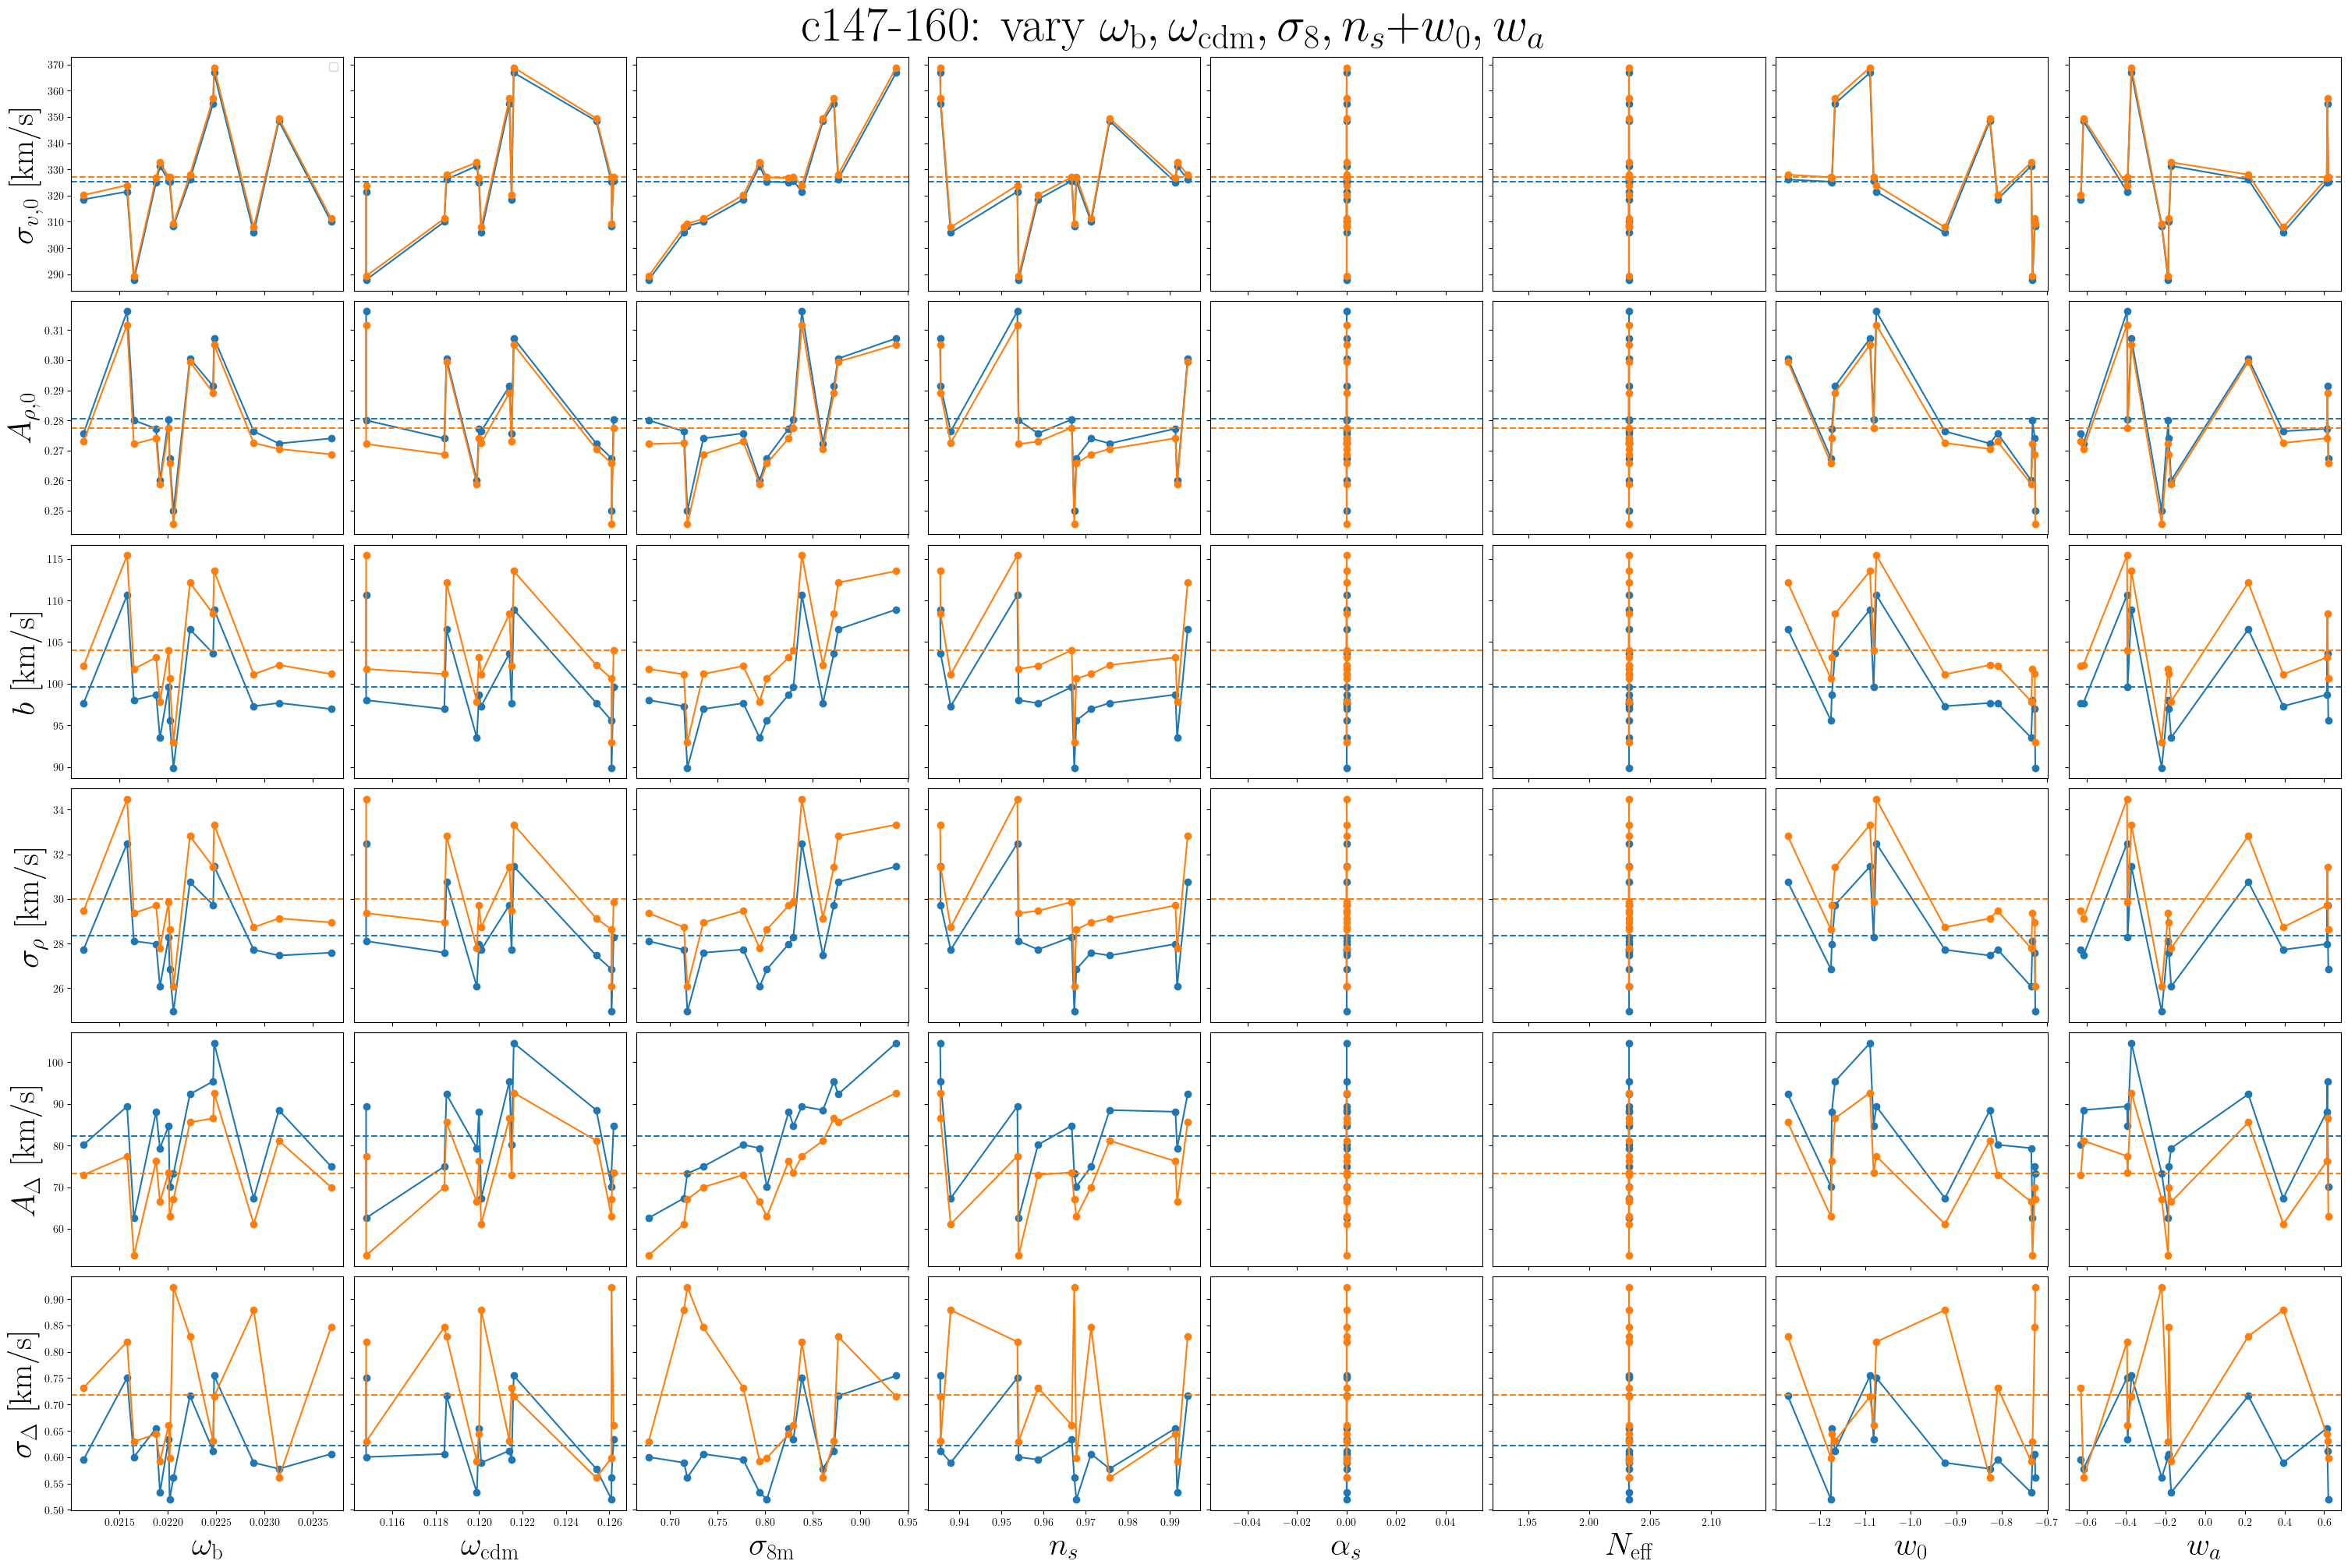

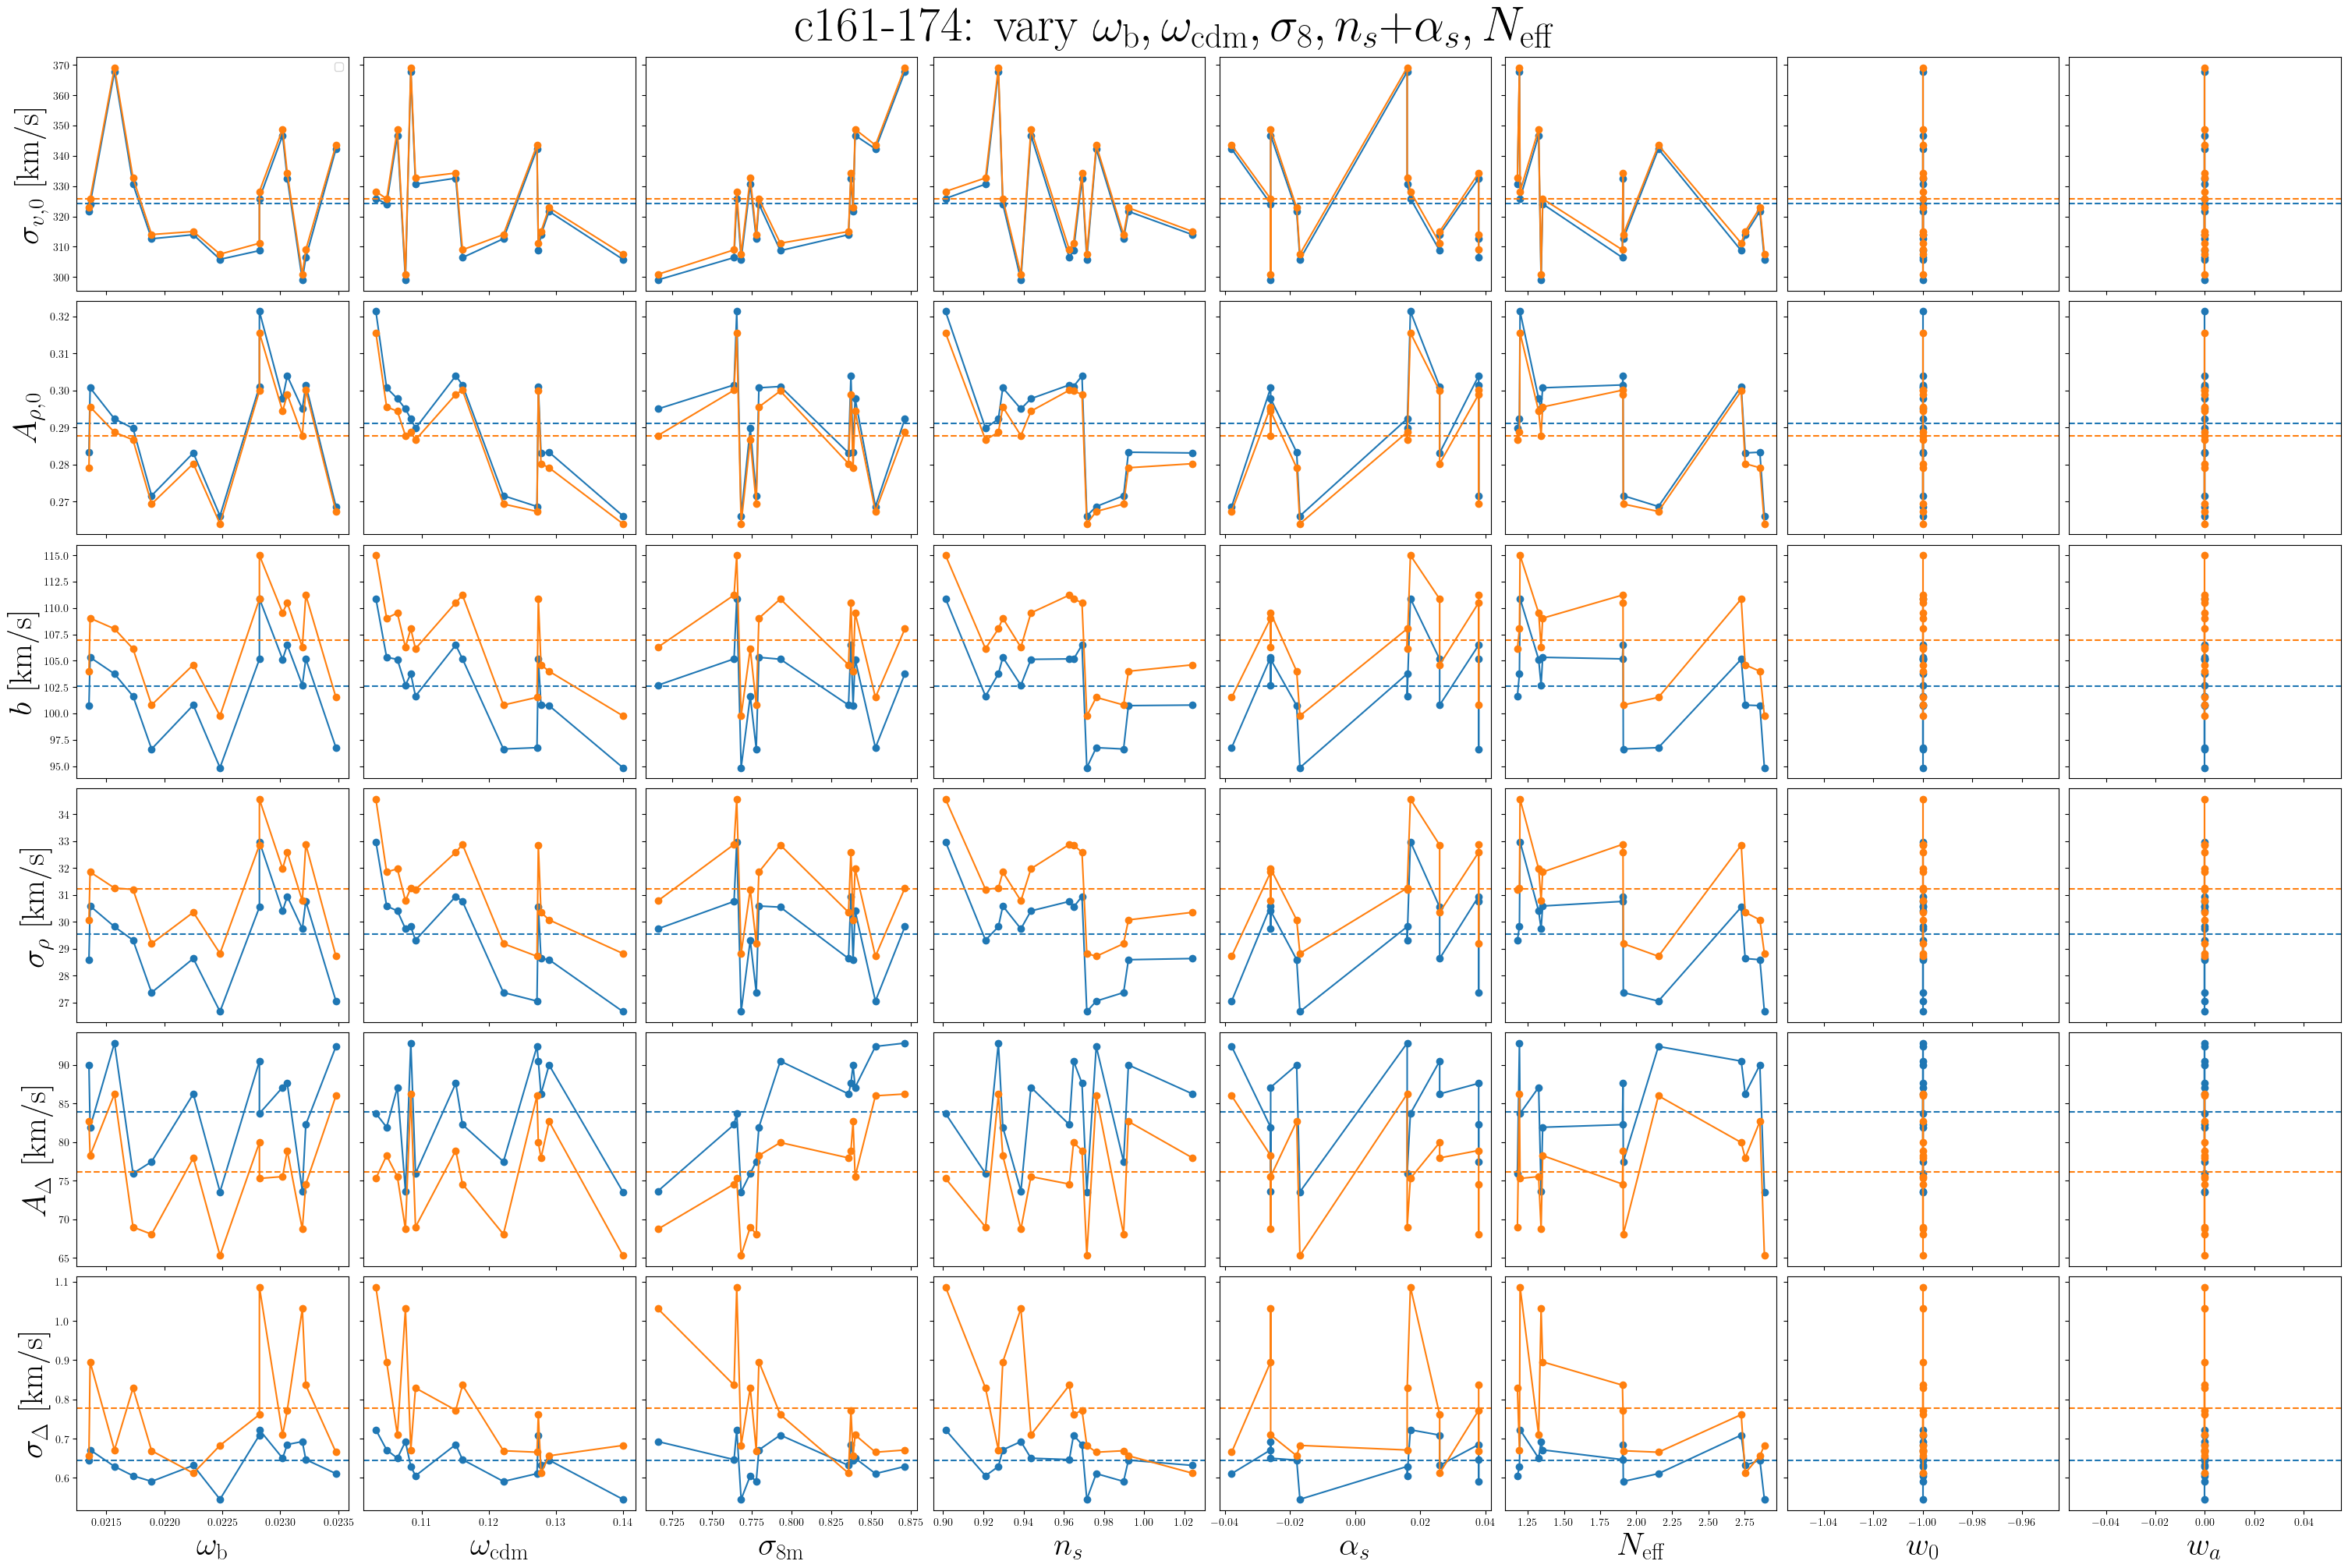

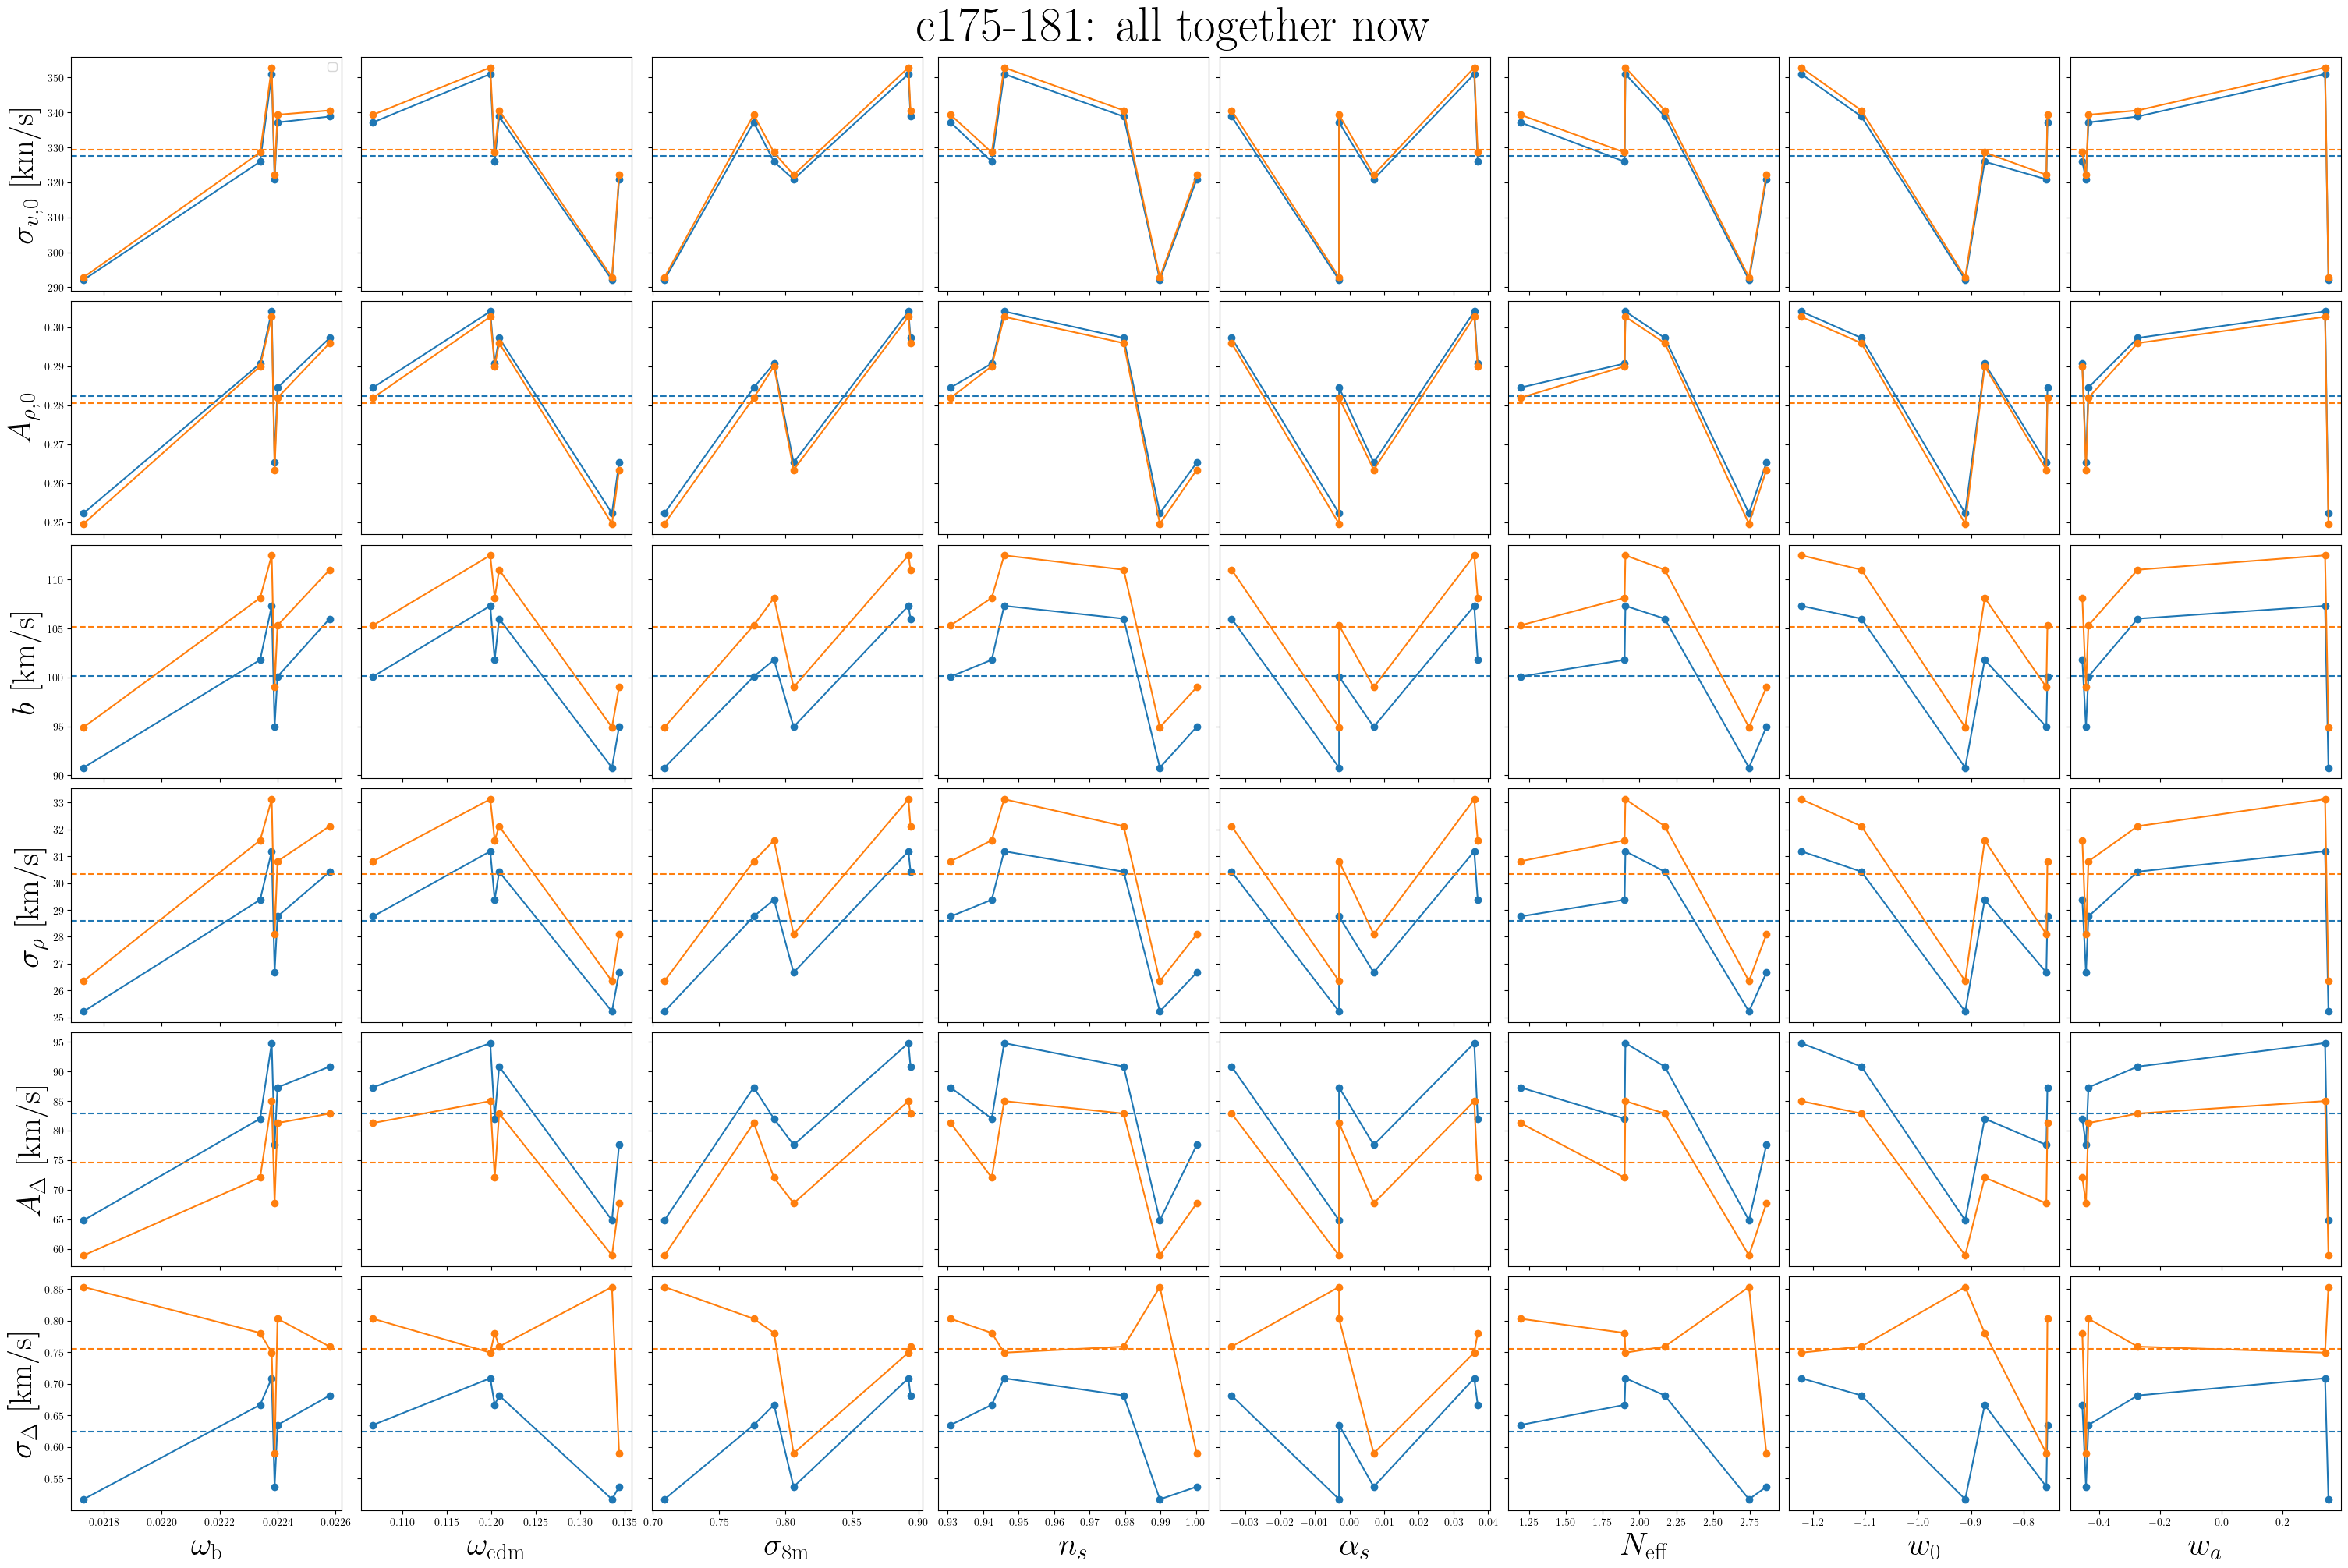

In [90]:

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]

c_labels = [r"$\omega_{\rm b}$", r"$\omega_{\rm cdm}$", r"$\sigma_{8\rm m}$", r"$n_s$", r"$\alpha_s$", r"$N_{\rm eff}$", r"$w_0$", r"$w_a$"]

mask_labels = [r"c130-146: vary $\omega_{\rm b}, \omega_{\rm cdm}, \sigma_8, n_s$", 
               r"c147-160: vary $\omega_{\rm b}, \omega_{\rm cdm}, \sigma_8, n_s$+$w_0, w_a$", 
               r"c161-174: vary $\omega_{\rm b}, \omega_{\rm cdm}, \sigma_8, n_s$+$\alpha_s, N_{\rm eff}$", 
               r"c175-181: all together now"]

lims = [(0.020, 0.248) , (0.1, 0.15), (0.64, 0.1), (0.9, 1.03), (-0.05,0.05), (1.0,3.1), (-1.35,-0.5), (-0.7,0.7)]

for m, mask in enumerate(masks):
    fig, ax = plt.subplots(6, 8, figsize=(30, 20), sharex='col', sharey='row', layout='constrained')

    for k in range(len(M_cens)):
        for i in range(len(labels)):
            for j in range(len(c_labels)):
                x_masked      = cosmo_arr[mask, j]
                params_masked = parameters[mask, k, i]

                order = np.argsort(x_masked)
                ax[i, j].plot(x_masked[order], params_masked[order], marker='o', c=f'C{k}')
                ax[i, j].axhline(np.nanmean(params_masked), c=f'C{k}', ls='--')
                
                #ax[i, j].axhline(fixed_parameters[i], c='k', ls='--', label=r'MDPL2 fit')
                ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
                #ax[i, j].margins(x=0)

            ax[i, 0].set_ylabel(labels[i], fontsize=30)

    ax[0, 0].legend(fontsize=10)

    fig.suptitle(mask_labels[m], fontsize=45)


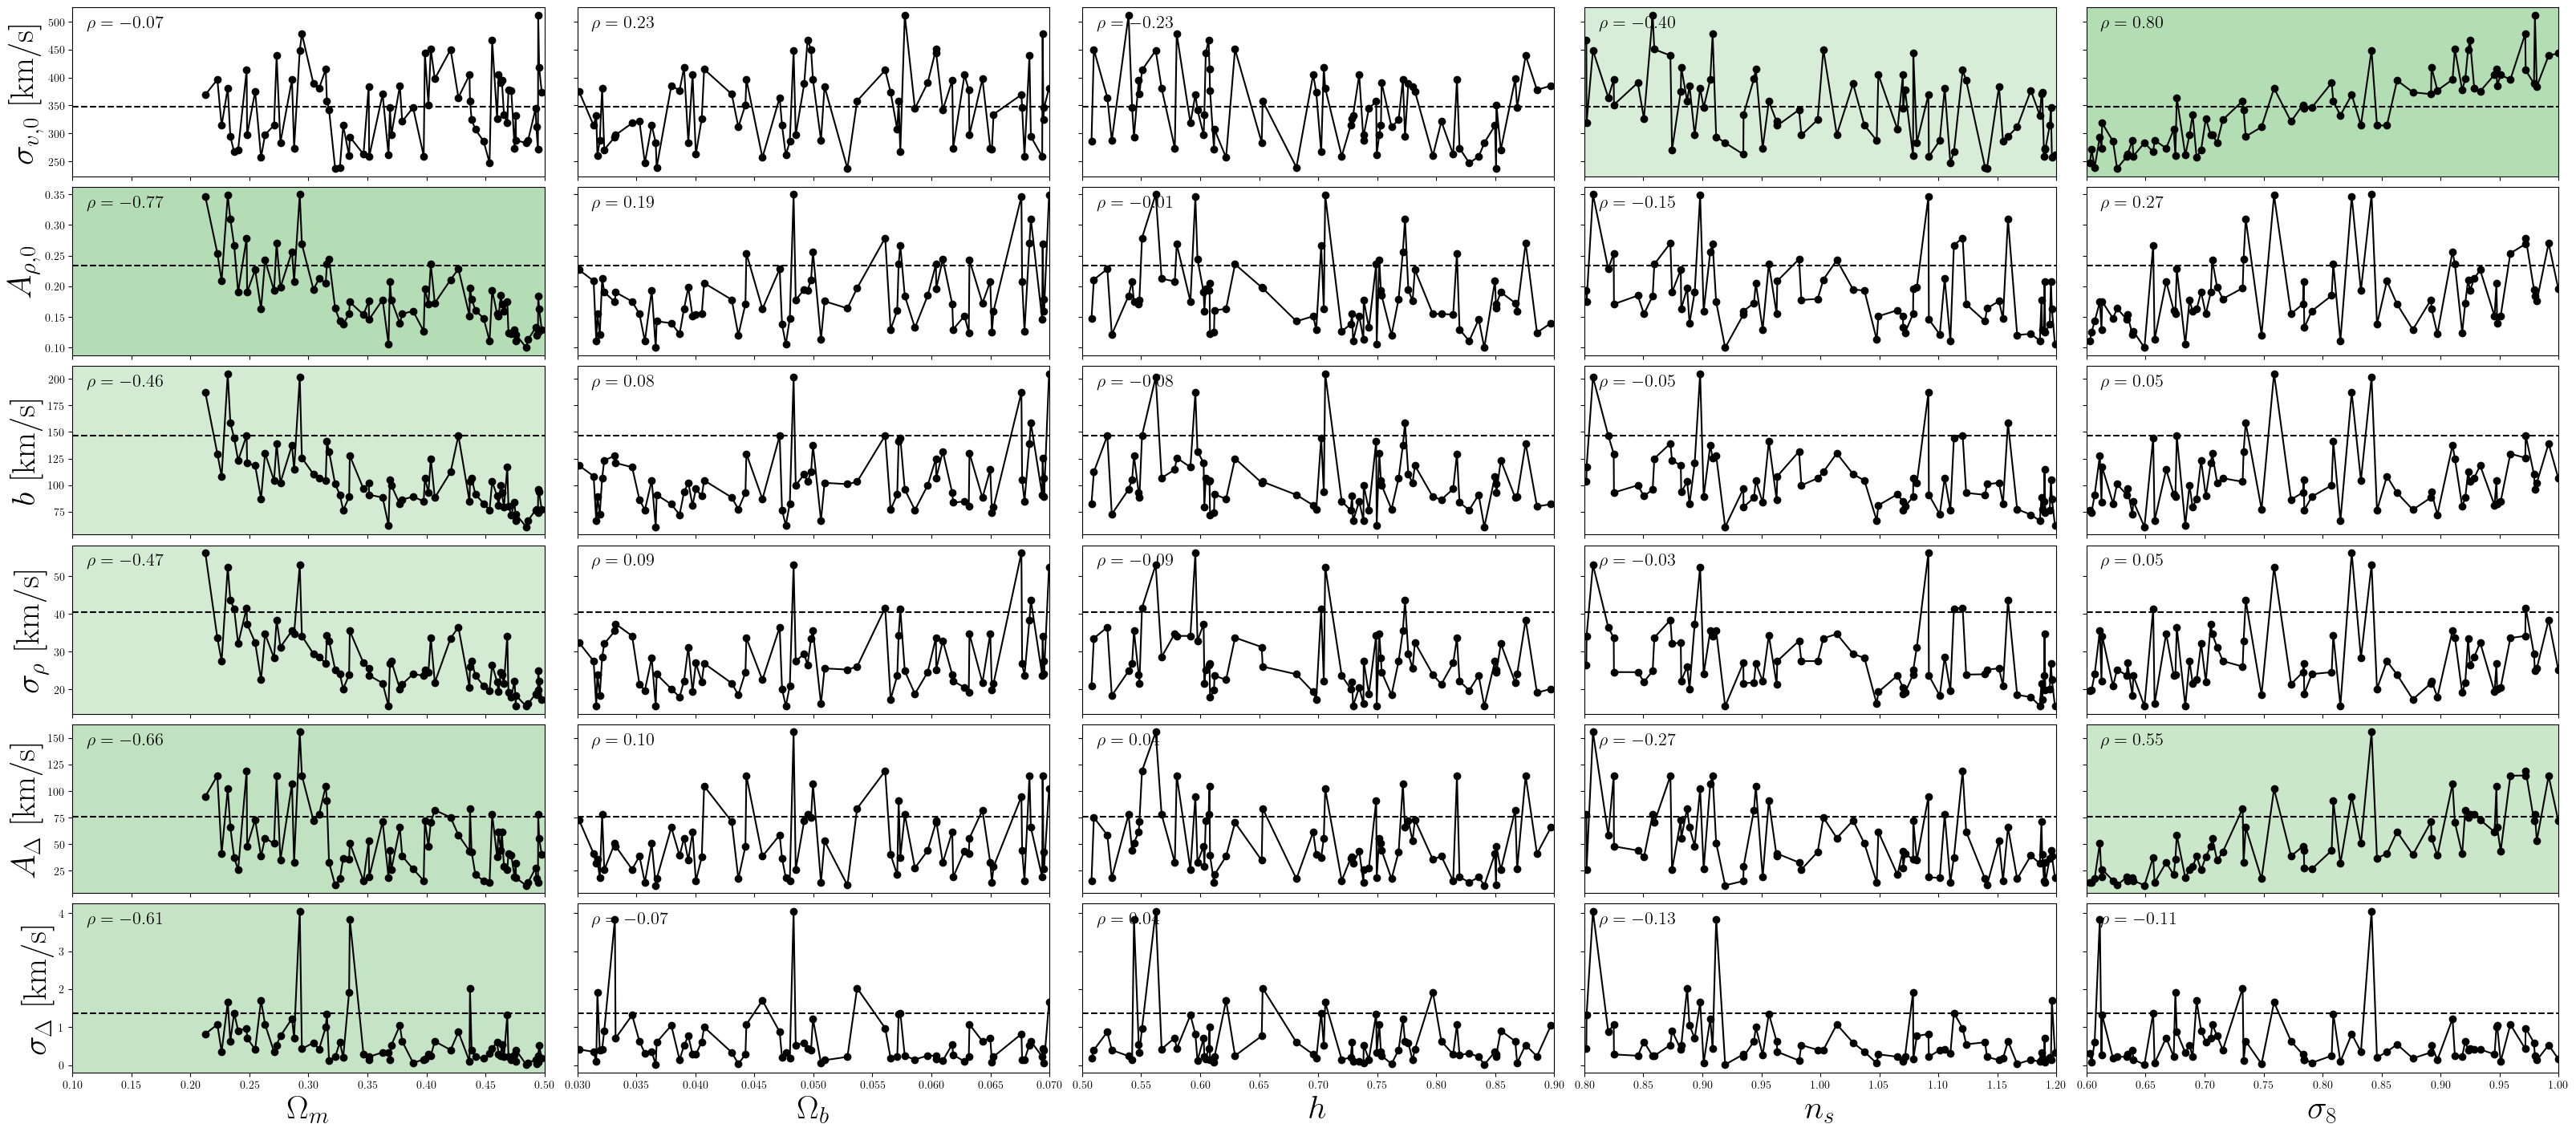

In [31]:
from scipy.stats import spearmanr, pearsonr
from matplotlib.colors import to_rgba

scale = 2
fig, ax = plt.subplots(6, 5, figsize=(16*scale, 7*scale), sharex='col', sharey='row', layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]

c_labels = [r"$\Omega_m$", r"$\Omega_b$", r"$h$", r"$n_s$", r"$\sigma_8$"]

lims = [[0.1, 0.5], [0.03, 0.07], [0.5, 0.9], [0.8, 1.2], [0.6, 1.0]]

ylims = [[190, 620], [0.1, 0.7], [0, 550], [0, 200], [0, 600], [0, 6.2]]

RHO_MIN = 0.0
P_MAX = 0.05 / (len(labels) * len(c_labels))
ALPHA_MAX = 0.45

for i in range(len(labels)):
    for j in range(len(c_labels)):
        x_plot = cosmo_arr[:, j]
        order = np.argsort(x_plot)

        mask = cosmo_arr[order, 0] > 0.2
        ax[i, j].plot(x_plot[order][mask], parameters[order, i][mask], marker='o', c='k')
        ax[i, j].axhline(np.nanmean(parameters[order, i]), c='k', ls='--')

        good = np.isfinite(parameters[:, i])
        rho, p = pearsonr(x_plot[good], parameters[good, i])
        dependent = (abs(rho) >= RHO_MIN) and (p < P_MAX)
        alpha = ALPHA_MAX * min(abs(rho), 1.0)
        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red', alpha if dependent else 0.0))
        ax[i, j].text(0.03, 0.95, rf'$\rho={rho:.2f}$', transform=ax[i, j].transAxes,
                      va='top', fontsize=16)

        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
        #ax[i, j].margins(x=0)
        ax[i, j].set_xlim(lims[j])
        #ax[i, j].set_ylim(ylims[i])

    ax[i, 0].set_ylabel(labels[i], fontsize=30)

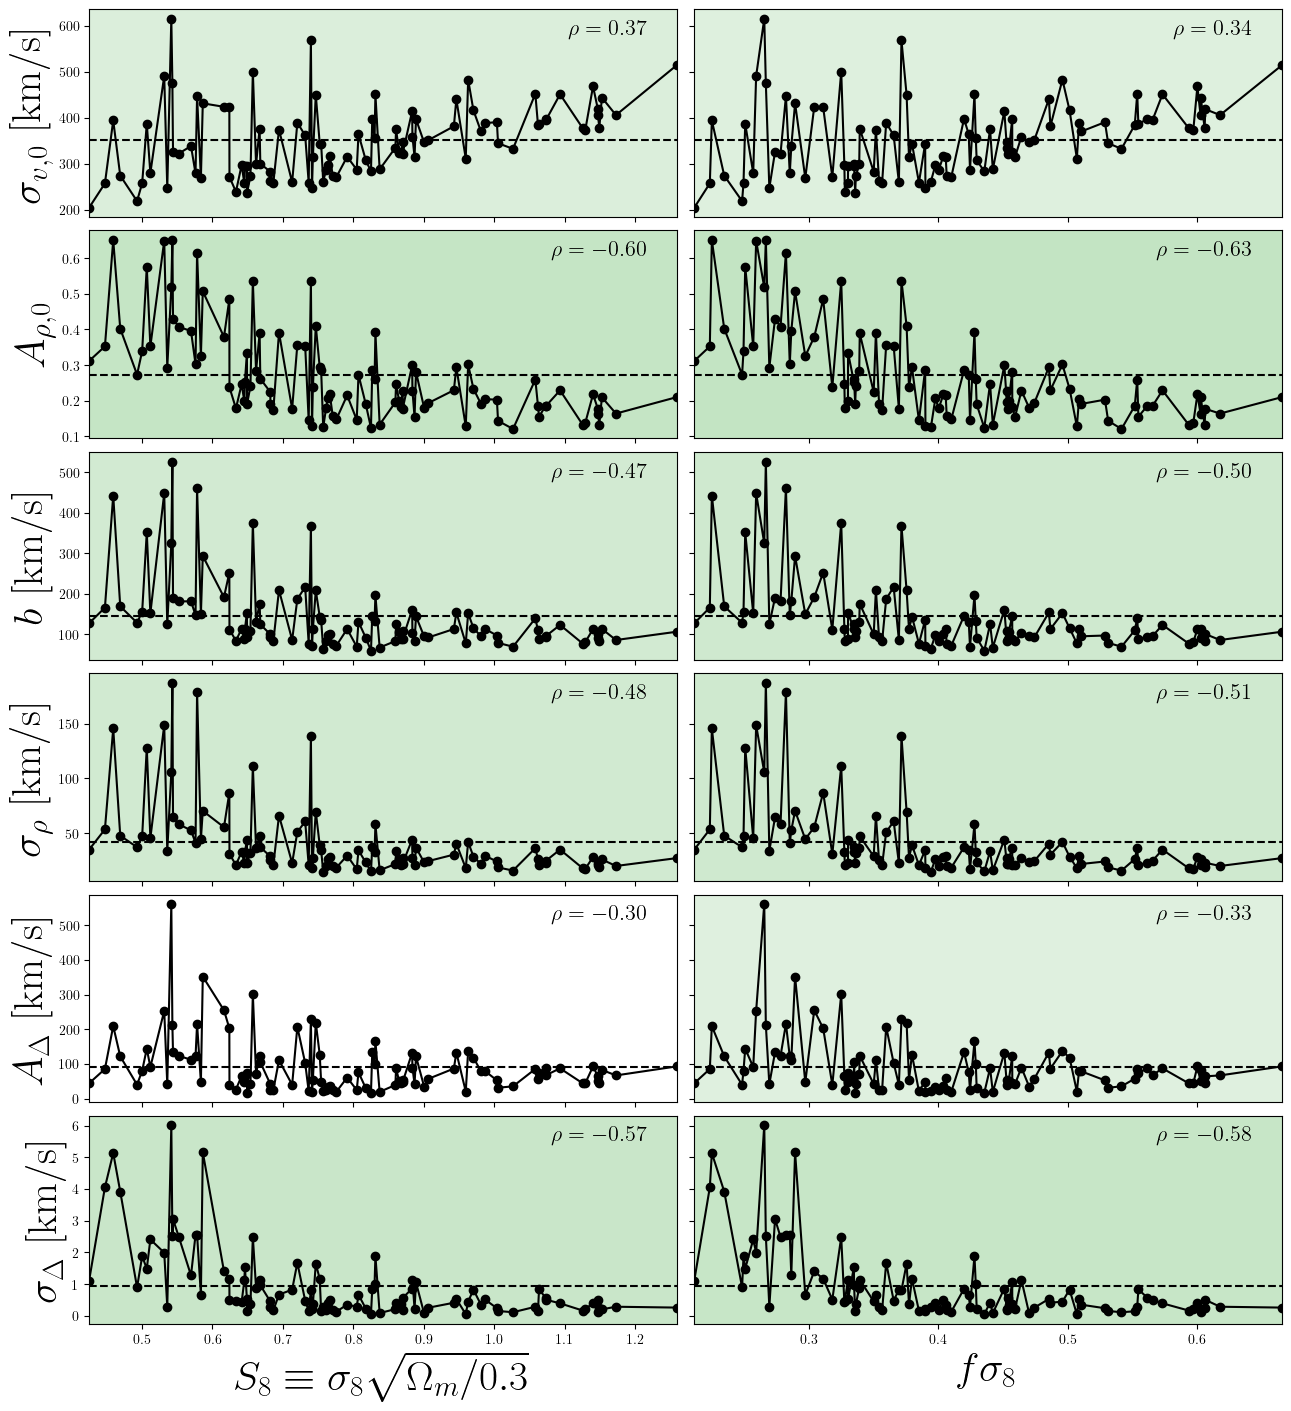

In [92]:
from matplotlib.colors import to_rgba

Z_SIM = 0.0
GAMMA = 0.55

Om, s8 = cosmo_arr[:, 0], cosmo_arr[:, 4]
S8 = s8 * np.sqrt(Om / 0.3)
fs8 = np.array([c.Om(Z_SIM)**GAMMA * s8[k] * c.growthFactor(Z_SIM)
                for k, c in enumerate(cosmos)])

derived = np.column_stack((S8, fs8))
d_labels = [r"$S_8 \equiv \sigma_8\sqrt{\Omega_m/0.3}$", rf"$f\sigma_8$"]

fig, ax = plt.subplots(6, 2, figsize=(16*scale*2/5, 7*scale), sharex='col', sharey='row', layout='constrained')

parameters = np.concatenate((sig_opts, del_opts), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]

RHO_MIN = 0.3
P_MAX = 0.05 / (len(labels) * len(d_labels))
ALPHA_MAX = 0.45

for i in range(len(labels)):
    for j in range(len(d_labels)):
        x_plot = derived[:, j]
        order = np.argsort(x_plot)
        ax[i, j].plot(x_plot[order], parameters[order, i], marker='o', c='k')
        ax[i, j].axhline(np.nanmean(parameters[:, i]), c='k', ls='--')

        good = np.isfinite(parameters[:, i])
        rho, p = pearsonr(x_plot[good], parameters[good, i])
        dependent = (abs(rho) >= RHO_MIN) and (p < P_MAX)
        alpha = ALPHA_MAX * min(abs(rho), 1.0)
        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red', alpha if dependent else 0.0))
        ax[i, j].text(0.95, 0.95, rf'$\rho={rho:.2f}$', transform=ax[i, j].transAxes,
                      va='top', ha='right', fontsize=16)

        ax[-1, j].set_xlabel(d_labels[j], fontsize=30)
        ax[i, j].margins(x=0)

    ax[i, 0].set_ylabel(labels[i], fontsize=30)

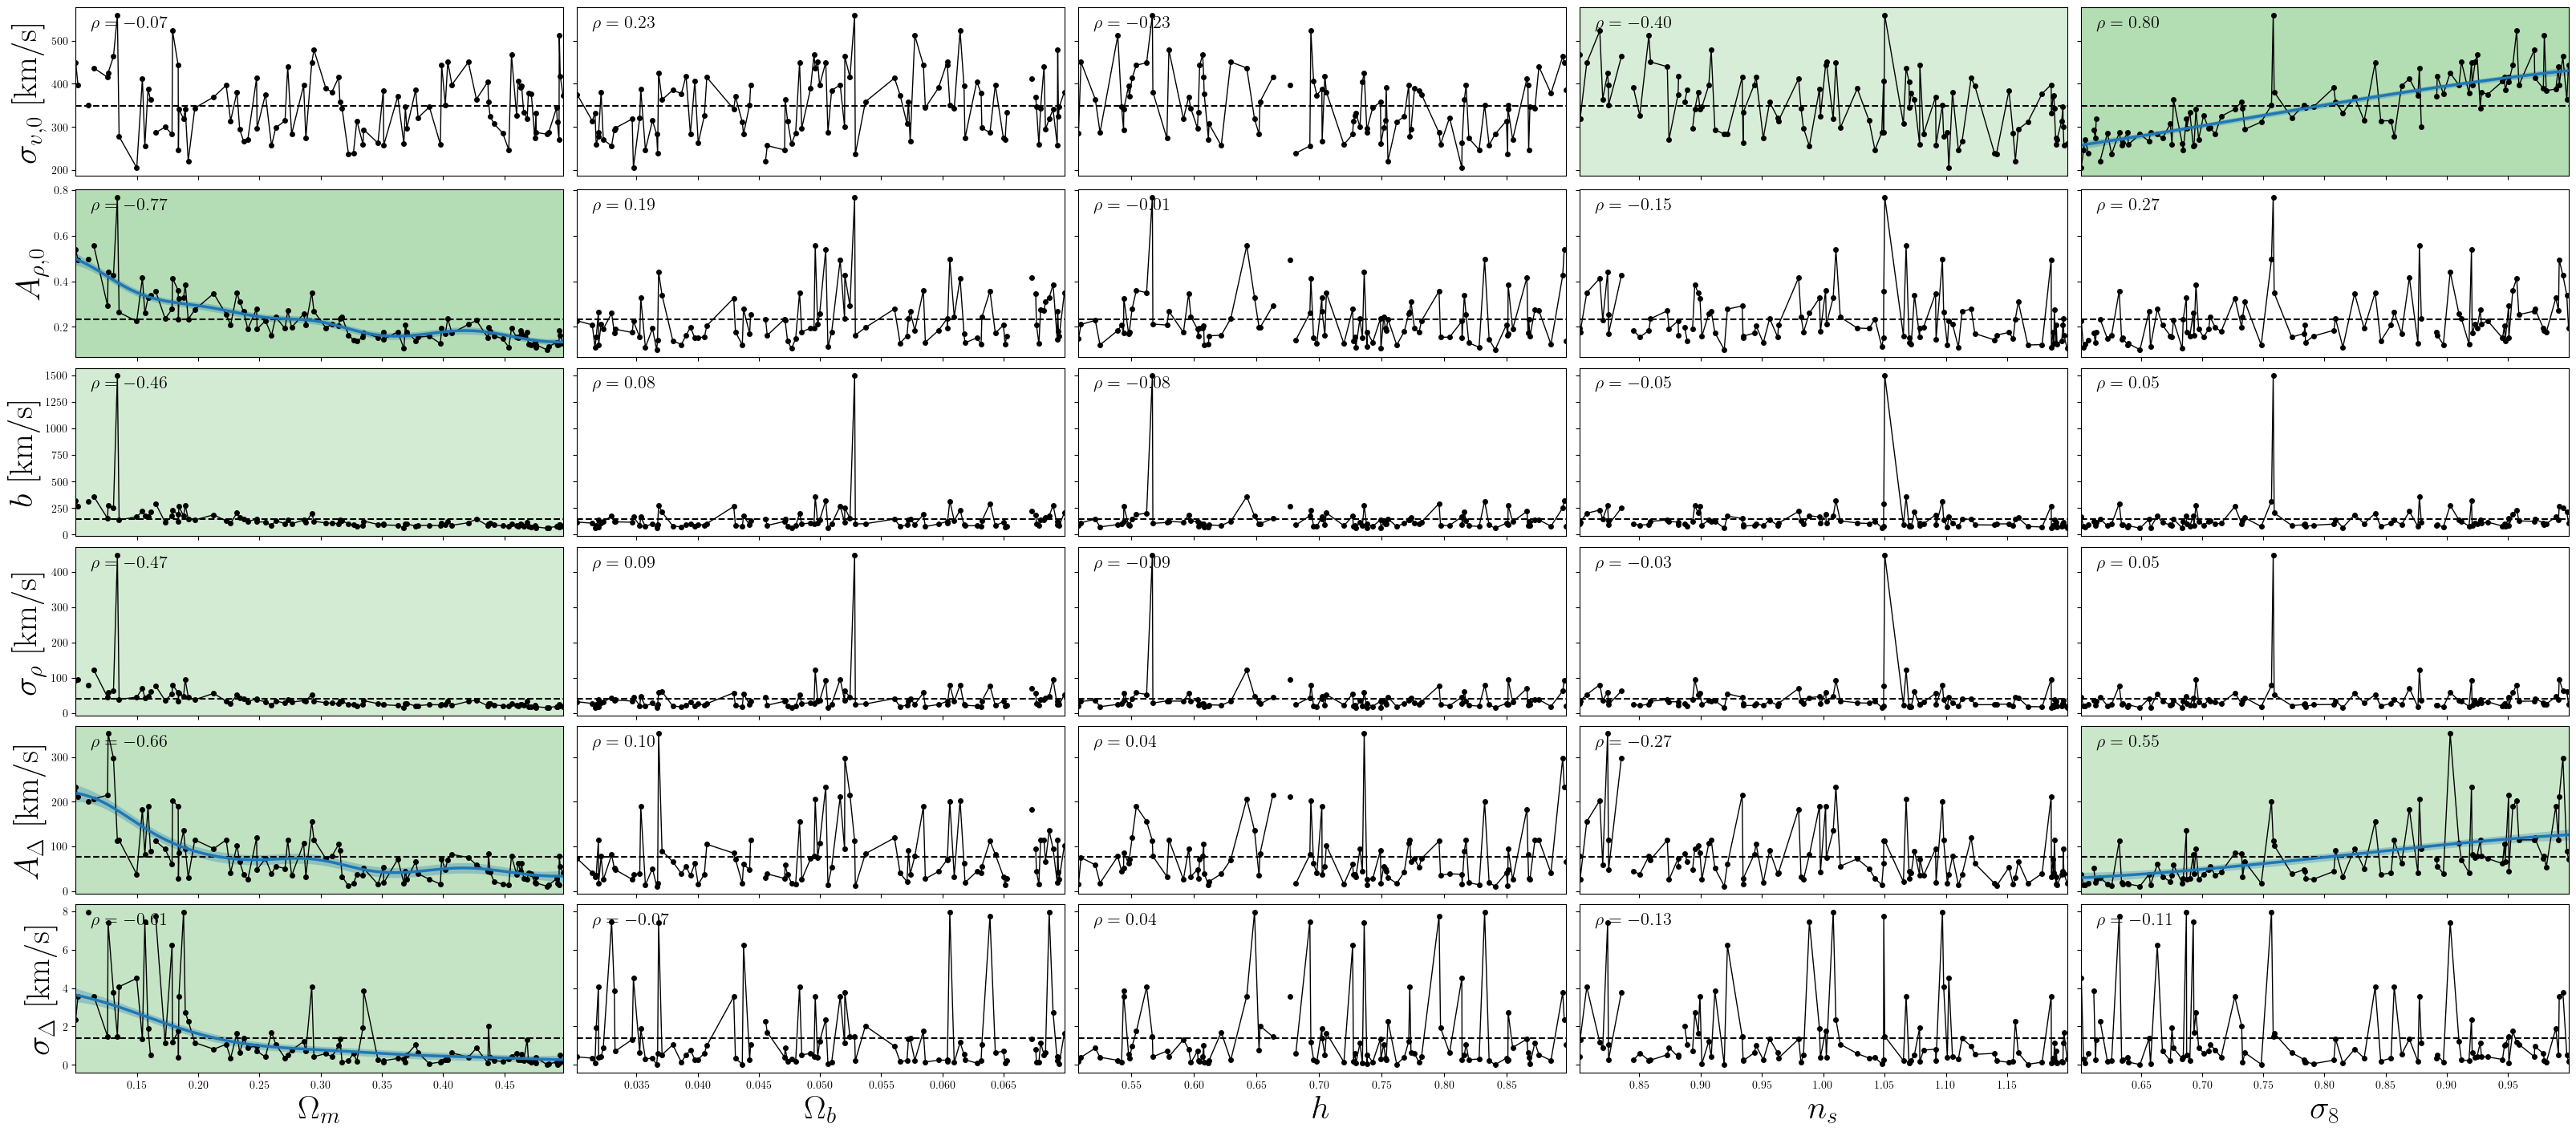

In [24]:
import numpy as np
import h5py
import george
from george import kernels
from scipy.optimize import minimize
from scipy.stats import spearmanr
from matplotlib.colors import to_rgba


def fit_panel_gp(x, y, yerr, n_restarts=3, seed=0):
    """1D george GP on standardized data. Returns a serializable record, or None."""
    x_mu, x_sd = x.mean(), x.std()
    y_mu, y_sd = y.mean(), y.std()
    xs, ys, es = (x - x_mu) / x_sd, (y - y_mu) / y_sd, yerr / y_sd

    kernel = np.var(ys) * kernels.Matern52Kernel(metric=1.0)
    gp = george.GP(kernel, white_noise=np.log(1e-2), fit_white_noise=True)
    gp.compute(xs, es)

    def nll(p):
        gp.set_parameter_vector(p)
        ll = gp.log_likelihood(ys, quiet=True)
        return -ll if np.isfinite(ll) else 1e25

    def grad_nll(p):
        gp.set_parameter_vector(p)
        return -gp.grad_log_likelihood(ys, quiet=True)

    rng = np.random.default_rng(seed)
    p0 = gp.get_parameter_vector()
    best = None
    for k in range(n_restarts):
        start = p0 if k == 0 else p0 + rng.normal(0, 1.0, size=p0.size)
        try:
            soln = minimize(nll, start, jac=grad_nll, method='L-BFGS-B')
        except (ValueError, np.linalg.LinAlgError):
            continue
        if soln.success and (best is None or soln.fun < best.fun):
            best = soln
    if best is None:
        return None

    return dict(pvec=best.x, xs=xs, ys=ys, es=es,
                x_mu=x_mu, x_sd=x_sd, y_mu=y_mu, y_sd=y_sd)


def gp_predict(rec, x_new):
    """Rebuild the GP from a record and predict in native units -> (mu, sd)."""
    kernel = np.var(rec['ys']) * kernels.Matern52Kernel(metric=1.0)
    gp = george.GP(kernel, white_noise=np.log(1e-2), fit_white_noise=True)
    gp.set_parameter_vector(rec['pvec'])
    gp.compute(rec['xs'], rec['es'])

    xn = (np.atleast_1d(x_new) - rec['x_mu']) / rec['x_sd']
    mu, var = gp.predict(rec['ys'], xn, return_var=True)
    return mu * rec['y_sd'] + rec['y_mu'], np.sqrt(np.maximum(var, 0)) * rec['y_sd']


fig, ax = plt.subplots(6, 5, figsize=(16*scale, 7*scale), sharex='col', sharey='row', layout='constrained')

parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$ [km/s]", r"$A_{\rho, 0}$", r"$b$ [km/s]", r"$\sigma_\rho$ [km/s]", r"$A_\Delta$ [km/s]", r"$\sigma_\Delta$ [km/s]"]
c_labels = [r"$\Omega_m$", r"$\Omega_b$", r"$h$", r"$n_s$", r"$\sigma_8$"]
c_names = ['Om', 'Ob', 'h', 'ns', 's8']
p_names = ['sig_v0', 'A_rho0', 'b', 'sig_rho', 'A_Del', 'sig_Del']

RHO_MIN = 0.3
RHO_FIT = 0.5
P_MAX = 0.05 / (len(labels) * len(c_labels))
ALPHA_MAX = 0.45

records = {}

for i in range(len(labels)):
    for j in range(len(c_labels)):
        x_plot = cosmo_arr[:, j]
        order = np.argsort(x_plot)
        ax[i, j].plot(x_plot[order], parameters[order, i], marker='o', c='k', lw=1, ms=4)
        ax[i, j].axhline(np.nanmean(parameters[:, i]), c='k', ls='--')

        good = np.isfinite(parameters[:, i]) & np.isfinite(errors[:, i]) & (errors[:, i] > 0)
        rho, p = pearsonr(x_plot[good], parameters[good, i])
        dependent = (abs(rho) >= RHO_MIN) and (p < P_MAX)
        ax[i, j].set_facecolor(to_rgba('tab:green' if dependent else 'tab:red',
                                       ALPHA_MAX * min(abs(rho) if dependent else 0.0, 1.0)))

        if abs(rho) >= RHO_FIT and good.sum() > 10:
            rec = fit_panel_gp(x_plot[good], parameters[good, i], errors[good, i])
            if rec is not None:
                rec['rho'] = rho
                records[(p_names[i], c_names[j])] = rec
                xg = np.linspace(x_plot[good].min(), x_plot[good].max(), 200)
                mu, sd = gp_predict(rec, xg)
                ax[i, j].fill_between(xg, mu - sd, mu + sd, color='tab:blue', alpha=0.3, lw=0)
                ax[i, j].plot(xg, mu, c='tab:blue', lw=2.5)

        ax[i, j].text(0.03, 0.95, rf'$\rho={rho:.2f}$', transform=ax[i, j].transAxes,
                      va='top', fontsize=16)
        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
        ax[i, j].margins(x=0)

    ax[i, 0].set_ylabel(labels[i], fontsize=30)


# GP_PATH = '/spiffball/cosweeney/simulations/Quijote/halos/latin_hypercube_HR/data/compact_gps.h5'

# with h5py.File(GP_PATH, 'w') as f:
#     f.attrs['kernel'] = 'Matern52'
#     f.attrs['basis'] = 'quijote'
#     f.attrs['n_sims'] = len(SIMS)
#     for (pname, cname), rec in records.items():
#         g = f.create_group(f'{pname}/{cname}')
#         for key in ('pvec', 'xs', 'ys', 'es'):
#             g.create_dataset(key, data=rec[key])
#         for key in ('x_mu', 'x_sd', 'y_mu', 'y_sd', 'rho'):
#             g.attrs[key] = rec[key]

# print(f'saved {len(records)} GPs to {GP_PATH}')

In [96]:
import camb

A_REF = 2.1e-9

def sigma8_ref(ombh2, omch2, H0, ns, As=A_REF):
    pars = camb.set_params(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=As,
                           mnu=0.0, omk=0.0, tau=0.0544, WantTransfer=True)
    pars.set_matter_power(redshifts=[0.0], kmax=10.0)
    pars.NonLinear = camb.model.NonLinear_none
    return camb.get_results(pars).get_sigma8_0()


def quijote_to_fit_basis(cosmo_arr):
    """(N,5) [Om, Ob, h, ns, s8] -> (N,4) [omega_c, omega_b, h, A_s]."""
    Om, Ob, h, ns, s8 = cosmo_arr.T
    omb = Ob * h**2
    omc = (Om - Ob) * h**2

    A_s = np.empty(len(cosmo_arr))
    for k in range(len(cosmo_arr)):
        s8_ref = sigma8_ref(omb[k], omc[k], 100 * h[k], ns[k])
        A_s[k] = A_REF * (s8[k] / s8_ref) ** 2

    return np.column_stack((omc, omb, h, A_s))

In [ ]:

GP_PATH = '/spiffball/cosweeney/simulations/Quijote/halos/latin_hypercube_HR/data/compact_gps.h5'

# which Quijote-basis variable each compact-model parameter is emulated against
EMULATOR_MAP = {
    'sig_v0':  's8',
    'A_rho0':  'Om',
    'b':       'Om',
    'sig_rho': 'Om',
    'A_Del':   'Om',
    'sig_Del': 'Om',
}


def load_gps(path=GP_PATH):
    recs = {}
    with h5py.File(path, 'r') as f:
        for pname, cname in EMULATOR_MAP.items():
            if pname not in f or cname not in f[pname]:
                raise KeyError(f'no saved GP for {pname} vs {cname} — check the fit threshold')
            g = f[pname][cname]
            recs[pname] = dict(pvec=g['pvec'][:], xs=g['xs'][:], ys=g['ys'][:], es=g['es'][:],
                               x_mu=g.attrs['x_mu'], x_sd=g.attrs['x_sd'],
                               y_mu=g.attrs['y_mu'], y_sd=g.attrs['y_sd'])
    return recs


def derived_from_fit_basis(omch2, ombh2, h, As, ns=0.9649):
    """{omega_c, omega_b, h, A_s} -> {Om, sigma8}, using the exact A_s proportionality."""
    Om = (omch2 + ombh2) / h**2
    s8_ref = sigma8_ref(ombh2, omch2, 100 * h, ns)      # from the earlier snippet
    s8 = s8_ref * np.sqrt(As / A_REF)
    return Om, s8


def predict_compact_params(recs, omch2, ombh2, h, As, ns=0.9649):
    """Returns {param: (mu, sd)} in native units."""
    Om, s8 = derived_from_fit_basis(omch2, ombh2, h, As, ns)
    derived = {'Om': Om, 's8': s8}

    out = {}
    for pname, cname in EMULATOR_MAP.items():
        mu, sd = gp_predict(recs[pname], derived[cname])
        out[pname] = (float(mu[0]), float(sd[0]))
    return out


recs = load_gps()
print(predict_compact_params(recs, omch2=0.1200, ombh2=0.02237, h=0.6736, As=2.1e-9))

{'sig_v0': (369.05673546885356, 7.820096266521763), 'A_rho0': (0.23560169123084362, 0.01596336512097936), 'b': (117.98708475862608, 11.56348859509178), 'sig_rho': (31.219800756719625, 4.512091974058666), 'A_Del': (75.3878593253823, 15.462138562206171), 'sig_Del': (0.5384381604371188, 0.14400005577788438)}


In [24]:
# quick check 

path = '/spiffball/baylihayes/Oasis/Quijote/test_latinhypercube1990_1/run_1990z2test2/catalogue.hdf5'

with h5.File(path, 'r') as hdf:
    print(hdf.keys())
    print(hdf['pos'][()].shape)
    print(hdf['vel'][()].shape)
    print(hdf['Norb'][()][(300< hdf['Norb'][()]) & (hdf['Norb'][()] < 400)].shape)
    print(hdf['NSUBS'][()][(300< hdf['NSUBS'][()]) & (hdf['NSUBS'][()] < 400)].shape)

<KeysViewHDF5 ['Halo_ID', 'LIDX', 'M200b', 'Morb', 'NSUBS', 'Norb', 'PID', 'R200b', 'RIDX', 'SLIDX', 'SRIDX', 'pos', 'vel']>
(874, 3)
(874, 3)
(94,)
(0,)
